In [ ]:
!pip install groq

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq
from google.colab import userdata
import time
import hashlib
import math
import getpass
import matplotlib.ticker as ticker
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Description**: This section is **tasked with** importing **raw data**. These datasets will be **handled** and transformed into an analysis inspired by the **SAP** ecosystem and **MRP** concepts to **enable** better decision-making.

**Data Ingestion Clarification**: The **data** has been **anonymized** to ensure the confidentiality of **private information**. The dataset originates from the **oil** and **gas** **industry** in **Venezuela**.

# **📊 EXECUTIVE SUMMARY & STRATEGIC RECOMMENDATIONS**

### **Key Data Insights & Financial Impact**

* **Dead Stock Optimization**: The analysis uncovered a staggering $2,703,561.52 locked in dead stock (materials with zero outbound demand). Procurement strategies must be restructured immediately, especially for shelf-life-sensitive materials like nitrile gloves, to mitigate holding costs and capital stagnation.

* **Leakage and Accountability Control**: A critical vulnerability was identified involving $7,511.06 in high-value dispatches (including Class A materials like 1 1/4" Rods) allocated to "UNSPECIFIED" departments. An immediate internal warehouse audit is recommended to enforce standard operating procedures and prevent financial blind spots.

* **Strategic Sourcing Anomalies**: By utilizing a modified grouped Z-Score approach, the system isolated key pricing anomalies and moderate deviations in critical components like the Power Cable 3/0. This provides the procurement team with leverage to renegotiate contract terms with outlying suppliers.

* **Supply Chain Flow Optimization**: Temporal concentration analysis proved that the inventory pipeline successfully absorbed a massive bulk purchase of 35,000 meters of **7 Strands Galvanized Steel Guy Wire 3/8"** in **2025**, tracking its sequential distribution downward. This pattern establishes an operational baseline for future Material Requirements Planning (MRP) forecasting.

# **RAW DATA INGESTION**

In [ ]:
file_id = '1uBav3QFrI2qR-cryxkGS8lwOXKCIWrRS'

In [ ]:
path = f'https://drive.google.com/uc?export=download&id={file_id}'

# **EXPLORATORY DATA INSPECTION**

**Description**: This **segment** provides a general view of how the data is **composed** and offers a first **insight** into the dataset.

## **1. REVIEWING THE DATASET STRUCTURE AND ADDITIONAL POSSIBLE SHEETS.**

In [ ]:
try:
  print(f'Starting connection with Google Drive...')
  with pd.ExcelFile(path) as exell:
    names = exell.sheet_names
  print(f'Successful connection and sheet structure read!')
except Exception as e:
  print(f"ERROR: Connection failed. Details: {e}")

Starting connection with Google Drive...
Successful connection and sheet structure read!


### **A. DATASET STRUCTURE: SHEETS COUNT**

In [ ]:
# Counting the number of sheets
count_sheet = len(names)

# Showing number of the sheets
print(f'The number of sheets is {count_sheet}.')

The number of sheets is 3.


### **B. DATASET STRUCTURE: SHEET NAMES**

In [ ]:
# Showing sheet names
print(f'The sheet names are the following: {(names)}.')

The sheet names are the following: ['ENTRADAS', 'SALIDAS', 'STOCK'].


**Conclusion**: This dataset has more than one sheet. It's necessary to create **three data frames** to handle them.

## **2. CREATING THE CORRESPONDING DATAFRAMES**

### **A. INVENTORY DATAFRAMES**

In [ ]:
with pd.ExcelFile(path) as data:
  df_entries = pd.read_excel(data, sheet_name= names[0])
  df_outputs = pd.read_excel(data, sheet_name= names[1])
  df_stock = pd.read_excel(data, sheet_name= names[2])

### **B. COLLECTING DATAFRAMES INTO A DICTIONARY**

In [ ]:
raw_dataframes = {'RAW ENTRIES': df_entries,
                  'RAW OUTPUTS':df_outputs,
                  'RAW STOCK': df_stock
                  }

## **3. INSPECTING DATAFRAME STRUCTURE**

In [ ]:
def dataframes_inspection(command, data, **args):
  for name, df in data.items():
    message = (f'{"-"*10}{name} DATAFRAME{"-"*10}')
    print(message)

    try:
      # Formating command
      name_command = command.replace('.', '')

      # Creating and executing the command
      exe = getattr(df, name_command)

      # if it is a method (like .info()) , it executes.
      if callable(exe):
        result = exe(**args)
        if result is not None:
          if hasattr(result, 'round'):
            display(result.round(2))
          else:
            display(result)

      # if it is a atribute it (like .shape), executes.
      else:
        display(exe)

    except AttributeError:
      print(f'ERROR: The command {command} is incorrect. Please recheck your input.')

    except TypeError as type_err:
      print(f"ERROR: Technical details: {type_err}")

    except Exception as e:
      print(f"Unexpected ERROR: Please recheck. Technical details: {e}")

    print('-'* len(message) + '\n')

In [ ]:
def first_observations(data):
 for name, df in data.items():
  try:
    message = (f'{"-"*10}{name} DATAFRAME{"-"*10}\n')
    print(message)

    # the first five observations
    print(f'{"-"*10}THE FIRST FIVE OBSERVATIONS{"-"*10}')
    display(df.head())

    # the last five observations
    print(f'{"-"*10}THE LAST FIVE OBSERVATIONS{"-"*10}')
    display(df.tail())

    print('-'* len(message) + '\n')

  except AttributeError:
    print(f"ERROR: Object '{name}' is not a valid pandas DataFrame and cannot be inspected.\n")

  except Exception as e:
    print(f"ERROR: Problem inspecting DataFrame '{name}'. Technical details: {e}\n")

### **A. NUMBER OF OBSERVATIONS AND VARIABLES IN THE DATAFRAMES**

In [ ]:
dataframes_inspection('shape', raw_dataframes)

----------RAW ENTRIES DATAFRAME----------


(1478, 9)

-----------------------------------------

----------RAW OUTPUTS DATAFRAME----------


(3643, 12)

-----------------------------------------

----------RAW STOCK DATAFRAME----------


(3336, 6)

---------------------------------------



### **B. DATA TYPES IN THE DATAFRAMES**

In [ ]:
# dataframes_inspection('info', raw_dataframes) ----> data inspection

**Conclusion**: The following **observations** were made: **First**, the **column** headers are in **Spanish**, they must be formatted to **English** **second**, the **features** contain **incorrect** data types. **Finally** **converting** to **uppercase** all the **lowercase**.

In [ ]:
# copies for data cleaning
copies_raw_df  = {name: df.copy() for name, df in raw_dataframes.items()}

#### **ENGLISH TRANSLATION COLUMNS SECTION**

In [ ]:
# translate all dataframes columns
trans_column = {
    'FECHA': 'DATE',
    'CANTIDAD': 'QUANTITY',
    'UNIDAD DE MEDIDA': 'UNIT_OF_MEASURE',
    'CANTIDAD': 'QUANTITY',
    'NOTA DE ENTREGA': 'DELIVERY_NOTE_N°',
    'EMPRESA': 'SUPPLIER',
    'P. U. $': 'UNIT_PRICE_USD',
    'OBSERVACION': 'REMARK',
    'GERENCIA SOLICITANTE': 'REQUESTING_DEPARTMENT',
    'SOLICITADO POR:': 'REQUESTED BY',
    'APROBADO POR:': 'APPROVED BY',
    'COD SAP': 'SAP_CODE',
    'Columna1': 'COLUMN1',
    'OBSERVACIONES / PARA DONDE SERÁ EMPLEADO EL MATERIAL VER SD': 'DESTINATION_REMARKS',
    'ENTRADAS': 'ENTRY',
    'SALIDAS': 'OUTPUT',
    'STOCK ACTUAL': 'CURRENT_STOCK',
    'NOTA DE ENTREGA N°': 'DELIVERY_NOTE_N°'
}

In [ ]:
for name in copies_raw_df.keys():
    copies_raw_df[name] = copies_raw_df[name].rename(columns=trans_column)

#### **CASTING COLUMNS TO CORRECT DATA TYPES**

In [ ]:
# convert data types to their correct format
f_date = ['DATE']
f_float = ['QUANTITY', 'UNIT_PRICE','ENTRY', 'OUTPUT', 'CURRENT_STOCK']
f_int = ['SAP_CODE', 'N°']
f_str = ['UNIT_OF_MEASURE']

In [ ]:
for df in copies_raw_df.values():
  for col in df.columns:

    # date format
    if col in f_date:
      df[col] = pd.to_datetime(df[col], errors='coerce')

    # float format
    if col in f_float:
      df[col] = pd.to_numeric(df[col], errors='coerce')

    # int format
    if col in f_int:
      df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    # string format
    if col in f_str:
      df[col] = df[col].astype(str)

In [ ]:
# dataframes_inspection('info', copies_raw_df) ----> recheking the info on all dataframes

### **C. NORMALIZING ALL STRING COLUMNS**

In [ ]:
# converting to uppercase and trimming leading/trailing whitespaces for string columns
for name in copies_raw_df.keys():
  # selecting dataframe
  df = copies_raw_df[name]

  # selecting only strings columns
  str_col = df.select_dtypes(include=['object']).columns

  # itering string columns for formating
  for col in str_col:
    df[col] = df[col].astype(str).str.strip().str.upper()

  # finally, it replaces "NAN" with actual nulls using np.nan
  copies_raw_df[name] = df.replace('NAN', np.nan)

### **D. VISUALIZATION  OF THE FIVE FIRST AND LAST FIVE OBSERVATIONS**

In [ ]:
# first_observations(copies_raw_df) -----> rechecking the first and last observations

**CONCLUSION**: I have **observed** there are **entirely null rows**. I must **delete** those rows. **Also**, I observe the **material names** and **descriptions** in **other columns** are typed in **Spanish**, I must **translate** them to **English** too.

### **E. DELETING ENTIRELY NULL ROWS**

In [ ]:
def drop_null_rows(dfs):
  for name in dfs.keys():
    try:
      # this section converts all zeros to nulls and it removes all entirely null rows
      dfs[name] = dfs[name].replace(0, np.nan).dropna(how='all')

      # it normalizes only numeric columns back to zero
      numeric_col = dfs[name].select_dtypes(include=[np.number]).columns
      dfs[name][numeric_col] = dfs[name][numeric_col].fillna(0)

    except AttributeError:
      print(f"ERROR: Object '{name}' is not a valid pandas DataFrame and cannot be inspected.\n")

    except Exception as e:
      print(f"ERROR: Problem inspecting DataFrame '{name}'. Technical details: {e}\n")


In [ ]:
# dropping rows that are completely null
drop_null_rows(copies_raw_df)

In [ ]:
# first_observations(copies_raw_df) -----> rechecking the first and last observations

### **F. CATEGORICAL DATA INSPECTION AND ENGLISH TRANSLATION**

#### **UNIQUE DESCRIPTIONS ANALYSIS**

In [ ]:
col_list = ['MATERIAL', 'REQUESTING_DEPARTMENT', 'DESTINATION_REMARKS', 'REMARK']

In [ ]:
def unique_description(dfs, columns):
  uni_data_list = []

  # iteration column names list
  for col in columns:
    unique_data = set()

    # Extracting unique values
    for df in dfs.values():
      try:
        if col in df.columns:
          unique_data.update(df[col].replace(0, np.nan).dropna())
      except Exception as e:
        print(f"ERROR: Problem extracting data for column '{col}'. Details: {e}")

    # saving the data
    uni_data_list.append(sorted(unique_data))

  return uni_data_list

In [ ]:
def report_description(dfs, columns):
  try:
    uniques = unique_description(dfs, columns)
    for i, col in enumerate(columns):
      data = uniques[i]

      # Displaying the report
      message = (f'{"-"*10}Unique descriptions in {col} column{"-"*10}')
      print(message)
      print(data)
      print(f'Total unique items: {len(data)}')
      print(f'{len(message)*"-"}\n')

  except Exception as e:
    print(f"ERROR: Problem generating the description report. Details: {e}\n")

In [ ]:
report_description(copies_raw_df, col_list)

----------Unique descriptions in MATERIAL column----------
['A/A 10 TON', 'ABRASADERA PARA POSTES DE 5-1/2"', 'ABRASADERA PARA POSTES DE 7-1/2"', 'ABRASADERA PARA POSTES DE 8-1/2"', 'ABRAZADERAS DE 3-1/2 PULGADAS', 'ABSORBENTE CRUDO BARRERA 8IN X 10FT', 'ACEITE 10W30 (PARA MOTORES DIESEL)', 'ACEITE 2 TIEMPOS', 'ACEITE DIESEL/GASOLINA 10W-30', 'ACEITE HIDRAULICO - ISO 68', 'ACEITE HIDRUALICO DR3', 'ACEITE LUB - OIL 15W-40 CI- 4/SL', 'ACEITE PDV 15W40', 'ACEITE PDV ENGRALUD ISO 220', 'ACEITE PDV MAXIDIESEL PLUS 50', 'ACEITE PDV TURBOLUB ISO 32', 'ACEITE PDV ULTRADIESEL', 'ACEITE SUPRA SEMI-SINTETIC 20W50', 'ACEITE TURBOLUB-OIL 68', 'ACOPLE  1-1/2" X 1"', 'ACOPLE  1-1/2" X 3/4"', 'ACOPLE DE 4" PARA BOMBA DE DRENAJE V-915', 'ACOPLE MOTOR/BOMBA BMF', 'ACOPLE SOLDABLE DE 1-1/2" X 1"', 'ACOPLE TIPO ESTRELLA  PARA BOMBA CENTRIFUGA P-202', 'ACOPLE TIPO ESTRELLA N°190 PARA BOMBA CENTRIFUGA P-202', 'ACTUALIZACION GAUMER DEL PANEL CALENTADOR DEL SKID DE GAS', 'ADAPTER A 4 1/16" A 3 1/8"', 'AILASDO

#### **English Translation**

**Note** Following the generation of the **industrial_supply_chain_logistics_translated**.xlsx file, these cells have been **preserved for documentation purposes**. This script manages the **automated translation logic** within the inventory system. Their role is now **strictly archival**, documenting the **data engineering workflow**. Although **inactive during execution**, maintaining them ensures **data consistency** and **reproducibility** across all analysis stages.

In [ ]:
es_descriptions = unique_description(copies_raw_df, col_list)

In [ ]:
try:
    api_key = userdata.get('grop_key_api')
except:
    api_key = getpass.getpass("Please, type API Key OF GROQ HERE: ")

In [ ]:
#  groq API configuration
client = Groq(api_key=api_key)
model = ("llama-3.3-70b-versatile")

In [ ]:
def get_translation(data):
  trans_dictionary = {}
  limit_chuck = 40

  # flattening the list
  data_list = [item for sublist in data for item in sublist]

  # batching data for translation
  for i in range(0, len(data_list), limit_chuck):

    batch = data_list[i: i + limit_chuck]

  # prompt for groq API
    prompt = f"""
[SYSTEM: MANDATORY FORMAT]
You are a data processing engine. Your output is used directly by a script.
Any text other than the translations will break the pipeline.

TASK: Translate from Spanish to English.
CONTEXT: Oil & Gas / Electrical Inventory.

STRICT RULES:
1. NO INTROS: Do not say "Here is the list" or anything else.
2. NO NUMBERS: Do not add "1.", "2.", or any numbering/bullets.
3. ONE PER LINE: Each line must contain exactly one translation.
4. QUANTITY: You must return exactly {len(batch)} lines.

### INPUT LIST:
{batch}

### OUTPUT (ONLY TRANSLATIONS):
"""
    try:
      # executing promt
      chat_completion = client.chat.completions.create(
              messages=[
                  {
                      "role": "user",
                      "content": prompt,
                  }
              ],
              model="llama-3.3-70b-versatile",
              temperature=0,
          )

      # translation text
      raw_text = chat_completion.choices[0].message.content

      # Converting to list and removing initial/final whitespace
      trans_list = [obj.strip() for obj in raw_text.strip().split('\n') if obj.strip()]

      # update dictionary
      trans_dictionary.update(zip(batch, trans_list))

    except Exception as e:
      print(f"ERROR: Failed to translate batch starting at index {i}. Technical details: {e}\n")

    # waiting 6 secons to avoid error with groq API
    time.sleep(6)
  return trans_dictionary



In [ ]:
new_file = 'industrial_supply_chain_logistics_translated.xlsx'
save_path = f'/content/drive/My Drive/data_sets/{new_file}'
# translate_descriptions = get_translation(es_descriptions)

In [ ]:
if os.path.exists(save_path):
  print(f'The file "{new_file}" already exists.')
else:
  translate_descriptions = get_translation(es_descriptions)
  print("The translation is finished.")

The file "industrial_supply_chain_logistics_translated.xlsx" already exists.


In [ ]:
if os.path.exists(save_path):
  print("The translation has already been completed.")
else:

  # apply the translations to all DataFrames in the dictionary
  for name, df in copies_raw_df.items():
    # select the str columns
    str_cols = df.select_dtypes(include='object').columns

    # replace original text with translated terms from the dictionary
    df[str_cols] = df[str_cols].replace(translate_descriptions)

    # translate the cells
    copies_raw_df[name] = df
  print("The changes have been successfully applied to the DataFrames.")

The translation has already been completed.


#### **EXPORT PROCESSED AND TRANSLATED DATA TO EXCEL**

In [ ]:
sheet_names = ['entries', 'outputs', 'stock']
new_file = 'industrial_supply_chain_logistics_translated.xlsx'
save_path = f'/content/drive/My Drive/data_sets/{new_file}'

if os.path.exists(save_path):
    print(f'The file "{new_file}" already exists. Overwrite prevented.')
else:
    with pd.ExcelWriter(save_path) as writer:
        for sheet_name, df in zip(sheet_names, copies_raw_df.values()):
            df.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f'The file "{new_file}" was created successfully.')

The file "industrial_supply_chain_logistics_translated.xlsx" already exists. Overwrite prevented.


# **GENERAL ECONOMIC IMPACT ANALYSIS**

## **1. TRANSLATION RAW DATA INGESTION**

In [ ]:
file_id_2 = '1EdI2cajF-eYOs2IaHX0oCFFTq5z3qPma'

In [ ]:
raw_data_path = f'https://drive.google.com/uc?export=download&id={file_id_2}'

In [ ]:
# Getting sheet names
with pd.ExcelFile(raw_data_path) as data:
  names = data.sheet_names

In [ ]:
# showing sheet names
print(names)

['entries', 'outputs', 'stock']


In [ ]:
# Loading the datasets
with pd.ExcelFile(raw_data_path) as data:
  raw_entries_df = pd.read_excel(data, sheet_name=names[0])
  raw_outputs_df = pd.read_excel(data, sheet_name=names[1])
  raw_stock_df = pd.read_excel(data, sheet_name=names[2])

In [ ]:
raw_dfs = {
    'RAW ENTRIES': raw_entries_df,
    'RAW OUTPUTS': raw_outputs_df,
    'RAW STOCK': raw_stock_df
}

## **2. VISUALIZATION OF THE FIVE FIRST AND LAST FIVE OBSERVATIONS**

In [ ]:
# first_observations(raw_dfs) -----> rechecking the first and last observations

**Conclusion**: Most **string columns** are in English. **However**, the **UNIT_OF_MEASURE column** contains **Spanish** values and lacks consistency (like PIEZA vs PZA). I will **translate** and **standardize** these values.

In [ ]:
new_names = ['CLEAN ENTRIES', 'CLEAN OUTPUTS', 'CLEAN STOCK']

In [ ]:
clean_dfs = {name: df.copy() for name, df in zip(new_names, raw_dfs.values())}

In [ ]:
# iterating through each sheet in the dictionary to uppercase all text data
for name, df in clean_dfs.items():
    text_cols = df.select_dtypes(include=['object']).columns

    clean_dfs[name][text_cols] = df[text_cols].apply(lambda x: x.str.upper())

## **3. UNIT_OF_MEASURE DATA TRANSLATION**

In [ ]:
target_col = ['UNIT_OF_MEASURE']

In [ ]:
unique_data =  unique_description(clean_dfs, target_col)

In [ ]:
print(f'Unique data: {unique_data}')

Unique data: [['BULTO', 'CAJA', 'CUÑETE', 'EQP', 'EQUIPO', 'GAL', 'GALON', 'JGO', 'JT', 'JTA', 'JTS', 'KIT', 'LITRO', 'LTS', 'M', 'METRO', 'MTS', 'PACA', 'PAQ', 'PAR', 'PIES', 'PIEZA', 'PQTE', 'PZA', 'ROL', 'ROLLO', 'SACO', 'TAMBOR', 'TUBO', 'UND']]


In [ ]:
# dictionary for translating
measure_dict = {
    # unit/ pieces
    'PIEZA': 'UNIT',
    'PZA': 'UNIT',
    'UND': 'UNIT',
    'PAR': 'PAIR',

    # Sets & Equipment
    'JGO': 'SET',
    'KIT': 'SET',
    'EQP': 'EQUIPMENT',
    'EQUIPO': 'EQUIPMENT',

    # liquids and containers
    'LITRO': 'LITER',
    'LTS': 'LITER',
    'GAL': 'GALLON',
    'GALON': 'GALLON',
    'TAMBOR': 'DRUM',
    'CUÑETE': 'BUCKET',
    'TUBO': 'TUBE',

    # length and weight
    'METRO': 'METER',
    'MTS': 'METER',
    'M': 'METER',
    'PIES': 'FEET',

    # packaging and storage
    'CAJA': 'BOX',
    'PAQ': 'PACKAGE',
    'PQTE': 'PACKAGE',
    'BULTO': 'BULK/PACKAGE',
    'SACO': 'SACK',
    'PACA': 'BALE',
    'ROLLO': 'ROLL',
    'ROL': 'ROLL'
}

In [ ]:
column_name = target_col[0]

In [ ]:
for name, df in clean_dfs.items():
  # checking if the column to update is in the dataframe
  if column_name in df.columns:

    # this section performs the update on the data column
    clean_dfs[name][target_col] = clean_dfs[name][target_col].replace(measure_dict)
    print(f"{name}: '{target_col}' column standardized.")


CLEAN ENTRIES: '['UNIT_OF_MEASURE']' column standardized.
CLEAN OUTPUTS: '['UNIT_OF_MEASURE']' column standardized.
CLEAN STOCK: '['UNIT_OF_MEASURE']' column standardized.


In [ ]:
# first_observations(clean_dfs) -----> rechecking the first and last observations

## **4. COUNT NULLS PER VARIABLE FOR EACH DATAFRAME**

In [ ]:
def null_table(data):
 for name, df in data.items():
  try:
    message = (f'{"-"*10}{name} DATAFRAME{"-"*10}')
    print(message)

    # null count
    count_null = df.isna().sum()

    # null porcente
    null_porcent = (count_null / len(df))

    # null table
    table = pd.DataFrame({
        'TOTAL NULLS': count_null,
        'NULL PORCENT': null_porcent
    })

    # formatted porcent
    report_df = table.style.format(
                                    {'NULL PORCENT': '{:.2%}'}
    )
    display(report_df)
    print('-'* len(message) + '\n')
  except AttributeError:
    print(f"ERROR: Object '{name}' is not a valid pandas DataFrame and cannot be analyzed for nulls.\n")

  except Exception as e:
    print(f"ERROR: Problem generating null report for DataFrame '{name}'. Technical details: {e}\n")

In [ ]:
# null_table(clean_dfs) ---> visualizing null values

## **5. DATA DROPPING AND IMPUTATION**

**Observation and coclusion**:  In the **initial stage**, **COLUMN1** lacks a descriptive header. In the **OUTPUTS table**, it is **99.89%** null, and in the **STOCK table**, it only **contains** row numbers for enumeration. **Those** two columns must be **dropped**.

In [ ]:
def drop_column(dfs, columns):
  for col in columns:
    for name, df in dfs.items():
      try:
        # analysis if the column is in the dataframe
        if col in df.columns:
          dfs[name].drop(columns=[col], inplace=True)

          print(f'Column {col} dropped on {name} table successfully.')

      except AttributeError:
        print(f"ERROR: Object '{name}' is not a valid pandas DataFrame and cannot be modified.\n")

      except Exception as e:
        print(f"ERROR: Problem dropping column '{col}' on table '{name}'. Technical details: {e}\n")

In [ ]:
drop_column(clean_dfs, ['COLUMN1'])

Column COLUMN1 dropped on CLEAN OUTPUTS table successfully.
Column COLUMN1 dropped on CLEAN STOCK table successfully.


**Observation**: During the **second iteration**, the **DATE columns have** null values. I will **perform** a quick inspection to **determine** if imputation is **feasible**.

In [ ]:
def show_null_row(dfs, column):
  # iterating through all columns
  for col in column:
    try:
      for name, df in dfs.items():
        # if the column name is in the dataframe, process it
        if col in df.columns and df[col].isna().any():
          message = (f'{"-"*10}{name} DATAFRAME{"-"*10} | null column reference: {col}')
          print(message)
          filter = df[df[col].isna()]
          display(filter)
          print(f'{'-'*len(message)}\n')

    except AttributeError:
      print(f"ERROR: Object '{name}' is not a valid pandas DataFrame and cannot be inspected.\n")

    except Exception as e:
      print(f"ERROR: Problem analyzing nulls for column '{col}' on table '{name}'. Details: {e}\n")

In [ ]:
show_null_row(clean_dfs, ['DATE'])

----------CLEAN ENTRIES DATAFRAME---------- | null column reference: DATE


,N°,DATE,MATERIAL,UNIT_OF_MEASURE,QUANTITY,DELIVERY_NOTE_N°,SUPPLIER,UNIT_PRICE_USD,REMARK
1150,1151,NaT,ROTARY HEAD WITH BELT AND PULLEYS BCP DOUBLE M...,UNIT,10,NaN,ELECTRA-NETWORK SUPPLY,35.24,ARRIVED ON 27-02-2025


-------------------------------------------------------------------------

----------CLEAN OUTPUTS DATAFRAME---------- | null column reference: DATE


,N°,DATE,MATERIAL,UNIT_OF_MEASURE,QUANTITY,REQUESTING_DEPARTMENT,REQUESTED BY,APPROVED BY,SAP_CODE,UNIT_PRICE_USD,DESTINATION_REMARKS
3435,3451,NaT,NaN,NaN,0,NaN,NaN,NaN,0,0.0,NaN


-------------------------------------------------------------------------



**Conclusion**: After inspection, I observed that in the **ENTRIES** dataframe, the missing value in the **DATE** column is documented within the **REMARK** column; therefore, I must **impute** that **date**. Additionally, in the **OUTPUTS** dataframe, rows with **null dates** are **entirely empty**, so they will be **dropped**.

In [ ]:
clean_dfs['CLEAN ENTRIES']['DATE'] = clean_dfs['CLEAN ENTRIES']['DATE'].fillna(pd.to_datetime('2025-02-27'))
clean_dfs['CLEAN OUTPUTS'].dropna(subset=['DATE'], inplace=True)

**Observation**: At a third **glance**, I **notice** that the **UNIT_OF_MEASURE** column **contains** many **null values**. I must **take** a look.

In [ ]:
# show_null_row(clean_dfs, ['UNIT_OF_MEASURE']) ----> visualizing rows with null values in 'UNIT_OF_MEASURE' column

**Observation and conclusion**: In the third **phase of treatment**, I **noticed** that the **ENTRIES** and **OUTPUTS** dataframes have null values in the **UNIT_OF_MEASURE** column. Additionally, I **noticed** some descriptions **are** in **Spanish**, so I will translate them. By first extracting the **unique values**, I will be able to determine the correct unit of measure. Finally, in the **STOCK** dataframe, where **UNIT_OF_MEASURE** is null, the entire row is empty, so I must **drop it**.

In [ ]:
clean_dfs['CLEAN STOCK'] = clean_dfs['CLEAN STOCK'].dropna(subset=['MATERIAL'])

In [ ]:
def find_unmapped_data(dfs, columns, null_reference):
  uniques = set()
  for col in columns:
    for df in dfs.values():
      try:
        # verify if the columns are in the dataframe
        if col in df.columns and null_reference in df.columns:
          # filter the data and save it
          uniques.update(df[df[null_reference].isna()][col].dropna())

      except AttributeError:
        print(f"ERROR: Object is not a valid pandas DataFrame for column '{col}'.\n")

      except Exception as e:
        print(f"ERROR: Problem finding unmapped data for column '{col}'. Details: {e}\n")

  try:
    return sorted(list(uniques))
  except Exception as e:
    print(f"WARNING: Could not sort the unique values due to mixed data types. Returning unsorted list. Details: {e}")
    return list(uniques)

In [ ]:
unmapped_materials = find_unmapped_data(clean_dfs, ['MATERIAL'], 'UNIT_OF_MEASURE')

In [ ]:
print(unmapped_materials)

['1 1/4" X 25 FT PIN X PIN ROD', '15 AMP MONOPOLAR BREAKER', '16 AMP BREAKER FOR RAIL DIM', '24 CONNECTION BOX', '4" X 300# WN RF FLANGE', 'BARRACUDA TERMINAL FOR 3/0 CABLE', 'BARRACUDA TYPE TERMINAL FOR ONE EYE FOR 3/0 CABLE', 'BCP OF 200-300 RPM WITH ROTOR AND CONNECTIONS MODEL 35-1600', 'BCP OF 200-300 RPM WITH ROTOR AND CONNECTIONS MODEL 66-1500', 'BCP OF 300-300 BPD 400 RPM WITH ROTOR AND CONNECTIONS', 'BELT 5V1180', 'BLACK MEDIUM TIRAP', 'BRAKE FLUIDS', 'CABLE 100 MTS #16 BLACK', 'COPPER BAR 1.5 MTS', 'CROSSOVER 4 1/2" EUE PIN X 5 1/2" LTC BOX', 'CRUDE OIL ABSORBENT BARRIER 8IN X 10FT', 'CURRENT TRANSFORMER 15-27 KVA', 'DIESEL ENGINE OIL FILTER P/N 90915-30002 ALT W-6357', 'ELECTRIC MOTOR 75HP USED (A67918)', 'ELECTRIC MOTOR 75HP USED (S09107101390001M0003)', 'ELECTRIC MOTOR 75HP,460V,60HZ,FRAME405T MODEL: TXC 405T75U6B SERIAL: 2404086-001', 'ENCAPSULATED THREE-PHASE TRANSFORMER 45 KVA', 'EXPANSIVE COMA SPRAY', 'FREQUENCY DRIVE 100 HP, 480V, 60 HZ, 138A, VDF1100C43A-00 MODEL', 'F

In [ ]:
print(len(unmapped_materials))

56


In [ ]:
error_translation = {
    'EXPANSIVE COMA SPRAY': 'EXPANSIVE FOAM SPRAY',
    'TEIPE 33': 'Electrical Tape 33',
    'TEIPE 23': 'Rubber Splicing Tape 23'
}

In [ ]:
def apply_translation(dfs, columns, trans_dictionary):
  for col in columns:
    for df in dfs.values():
      try:
        # verify if the column exists in the dataframe
        if col in df.columns:
          # apply the translation
          df.loc[:,col] = df[col].replace(trans_dictionary)

      except AttributeError:
        print(f"ERROR: Object is not a valid pandas DataFrame for column '{col}'.\n")

      except Exception as e:
        print(f"ERROR: Problem applying translation for column '{col}'. Details: {e}\n")

  print(f'Translation was done successfully.')

In [ ]:
apply_translation(clean_dfs, ['MATERIAL'],error_translation )

Translation was done successfully.


In [ ]:
# dictionary to standardize units of measure
material_unit_map = {
    # Already translated
    'EXPANSIVE FOAM SPRAY': 'CAN',
    'Electrical Tape 33': 'ROLL',
    'Rubber Splicing Tape 23': 'ROLL',

    # equipment
    'BCP OF 200-300 RPM WITH ROTOR AND CONNECTIONS MODEL 66-1500': 'EQUIPMENT',
    'BCP OF 300-300 BPD 400 RPM WITH ROTOR AND CONNECTIONS': 'EQUIPMENT',
    'BCP of 200-300 RPM with Rotor and Connections MODEL 35-1600': 'EQUIPMENT',
    'ELECTRIC MOTOR 75HP USED (A67918)': 'EQUIPMENT',
    'ELECTRIC MOTOR 75HP USED (S09107101390001M0003)': 'EQUIPMENT',
    'ENCAPSULATED THREE-PHASE TRANSFORMER 45 KVA': 'EQUIPMENT',
    'Electric Motor 75HP,460V,60HZ,FRAME405T MODEL: TXC 405T75U6B SERIAL: 2404086-001': 'EQUIPMENT',
    'FREQUENCY DRIVE 100 HP, 480V, 60 HZ, 138A, VDF1100C43A-00 MODEL': 'EQUIPMENT',
    'Frequency Variator of 150 HP, 480V, 60 HZ, 180A, MFC 1000 Type': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 60HP (1009313303)': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 60HP (4W093J05-077)': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 60HP (AU81272)': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 60HP (AX75139)': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 75HP (09100904)': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 75HP (1029403657)': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 75HP (11107101390001M0075)': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 75HP (1W03J35-005)': 'EQUIPMENT',
    'USED ELECTRIC MOTOR 75HP (1W03J35-0054)': 'EQUIPMENT',
    'WEG THREE-PHASE MOTOR NEMA 75 HP 230/460V 1200 RPM': 'EQUIPMENT',

    # units
    '1 1/4" X 25 FT PIN X PIN ROD': 'UNIT',
    '15 AMP MONOPOLAR BREAKER': 'UNIT',
    '16 AMP BREAKER FOR RAIL DIM': 'UNIT',
    '24 CONNECTION BOX': 'UNIT',
    '4" X 300# WN RF FLANGE': 'UNIT',
    'BELT 5V1180': 'UNIT',
    'Belt 5V1180': 'UNIT',
    'BLACK MEDIUM TIRAP': 'PACKAGE',
    'Barracuda Terminal for 3/0 Cable': 'UNIT',
    'Barracuda Type Terminal for one eye for 3/0 Cable': 'UNIT',
    'COPPER BAR 1.5 MTS': 'UNIT',
    'CROSSOVER 4 1/2" EUE PIN X 5 1/2" LTC BOX': 'UNIT',
    'CRUDE OIL ABSORBENT BARRIER 8IN X 10FT': 'UNIT',
    'CURRENT TRANSFORMER 15-27 KVA': 'UNIT',
    'DIESEL ENGINE OIL FILTER P/N 90915-30002 ALT W-6357': 'UNIT',
    'Gasket Sheet': 'UNIT',
    'Gauge of 0-600 PSI': 'UNIT',
    'Industrial Breaker of 1250 AMP': 'UNIT',
    'Industrial Breaker of 250 AMP': 'UNIT',
    'POLYPROPYLENE SAFETY HELMET HIGH IMPACT WING TYPE CAP': 'UNIT',
    'POST CLAMP FOR 5-1/2"': 'UNIT',
    'Panel Breaker of 10 AMP': 'UNIT',
    'Panel Breaker of 20 AMP': 'UNIT',
    'Photo Cell with Base': 'UNIT',
    'REFLECTOR TYPE LIGHTING 400 W DEGREE OF PROTECTION IP66': 'UNIT',
    'TERMINAL': 'UNIT',
    'TIRES 26570R16': 'UNIT',
    'Tires 26570R16': 'UNIT',
    'TORQUE ANCHOR 9 5/8': 'UNIT',

    # sets, Pairs and lengths
    'JGO DADO 1/2IN DESDE 3/8 A 1-1/4': 'SET',
    'JGO DESTORNILL URREA 9700C O SIMILAR 5': 'SET',
    'LEATHER GLOVES': 'PAIR',
    'Pointed Gloves': 'PAIR',
    'CABLE 100 MTS #16 BLACK': 'ROLL',
    'RAGS': 'KILOGRAM',
    'Brake Fluids': 'CAN'
}

In [ ]:
def impute_from_reference(dfs, column_fill, reference_column, fill_dict):
  for df in dfs.values():
    try:
      if column_fill in df.columns and reference_column in df.columns:
        df.loc[:, column_fill] = df[column_fill].fillna(df[reference_column].map(fill_dict))

    except AttributeError:
      print(f"ERROR: Object is not a valid pandas DataFrame for column '{column_fill}'.\n")

    except Exception as e:
      print(f"ERROR: Problem imputing column '{column_fill}' from reference '{reference_column}'. Details: {e}\n")

  print(f'The {column_fill} was filled successfully.')

In [ ]:
impute_from_reference(clean_dfs, 'UNIT_OF_MEASURE', 'MATERIAL', material_unit_map)

The UNIT_OF_MEASURE was filled successfully.


In [ ]:
# null_table(clean_dfs) ---> visualizing null values

In [ ]:
# show_null_row(clean_dfs, ['MATERIAL', 'UNIT_OF_MEASURE']) ------> visualizing rows with null values in MATERIAL and UNIT_OF_MEASURE columns

**Conclusion**: Rechecking the **MATERIAL** and **UNIT_OF_MEASURE** columns, I **noticed** that the data in those rows is **almost entirely null**, so I chose to **drop** them.

In [ ]:
clean_dfs['CLEAN OUTPUTS'].dropna(subset=['MATERIAL', 'UNIT_OF_MEASURE'], inplace=True)

In [ ]:
# null_table(clean_dfs) ---> visualizing null values

In [ ]:
# show_null_row(clean_dfs, ['DELIVERY_NOTE_N°']) ------> visualizing rows with null values in the DELIVERY_NOTE_N° column

In [ ]:
report_description(clean_dfs, ['DELIVERY_NOTE_N°'])

----------Unique descriptions in DELIVERY_NOTE_N° column----------
['1', '1 (PARCIAL)', '10', '100', '101', '102', '103', '104', '107', '108', '110', '112', '113', '114', '116', '120', '125', '126', '128', '129', '130', '133', '134', '135', '136', '146', '156', '157', '16', '160', '161', '163', '165', '166', '169', '17', '170', '175', '176', '177', '180', '181', '182', '183', '185', '186', '187', '188', '189', '190', '191', '193', '194', '195', '196', '197', '198', '199', '2', '201', '2024-0001', '2024-0002', '2024-0003', '2024-0004', '2024-0005', '2024-0006', '2024-0007', '2024-0008', '204', '205', '207', '208', '217', '221', '222', '224', '225', '227', '230', '237', '238', '239', '240', '241', '242', '243', '244', '247', '249', '250', '251', '252', '253', '254', '255', '257', '258', '259', '260', '262', '263', '264', '267', '268', '269', '27', '271', '272', '273', '274', '275', '276', '277', '278', '279', '280', '281', '282', '283', '284', '286', '287', '288', '289', '291', '292', '2

**Observation and Conclusion**: Upon the **fourth refinement**, I noticed that the **DELIVERY_NOTE_N°** column has **40 null values**, representing **2.71%** of the total. I will fill these with the label **NOT SPECIFIED**. Additionally, I identified inconsistent entries such as **NE-** and **X**; I will categorize these as **TYPO** since they do not follow a valid nomenclature. Furthermore, I detected an error in the **UNIT_OF_MEASURE** column where some values were labeled as **Return**; I will investigate and apply the correct units.

In [ ]:
clean_dfs['CLEAN ENTRIES']['DELIVERY_NOTE_N°']  = clean_dfs['CLEAN ENTRIES']['DELIVERY_NOTE_N°'].fillna('NOT SPECIFIED')

In [ ]:
error_typo = {
    'NE-': 'TYPO',
    'X': 'TYPO'
}

In [ ]:
clean_dfs['CLEAN ENTRIES']['DELIVERY_NOTE_N°'] = clean_dfs['CLEAN ENTRIES']['DELIVERY_NOTE_N°'].replace(error_typo)

In [ ]:
clean_dfs['CLEAN ENTRIES'][clean_dfs['CLEAN ENTRIES']['MATERIAL'] == '12 VDC-100 A/20H BATTERY']

,N°,DATE,MATERIAL,UNIT_OF_MEASURE,QUANTITY,DELIVERY_NOTE_N°,SUPPLIER,UNIT_PRICE_USD,REMARK
1274,1275,2025-11-02,12 VDC-100 A/20H BATTERY,UNIT,10,397,INDUSTRIAL GLOBAL SOLUTIONS,323.93,ODS
1412,1411,2026-01-16,12 VDC-100 A/20H BATTERY,UNIT,6,NOT SPECIFIED,RETURN,313.90,RETURN


**Conclusion**: After **analyzing** the records for the **12 VDC-100 A/20H BATTERY**, I found that the unit price is highly consistent across entries. Since there is only one unique supplier associated with this material in previous records, I have determined that the **Return** value in the **SUPPLIER** column is a typing error. Therefore, I will impute the correct supplier based on historical data.

In [ ]:
clean_dfs['CLEAN ENTRIES']['SUPPLIER'] = clean_dfs['CLEAN ENTRIES']['SUPPLIER'].replace('Return', 'INDUSTRIAL GLOBAL SOLUTIONS')

**Observation and Conclusion**: In the **fifth inspection stage**, I noticed that the **REMARK** column has **73.75% null values**, which constitutes mostly **useless data**. Additionally, this column **is not** essential for the analysis; therefore, I have decided to **drop it**.

In [ ]:
clean_dfs['CLEAN ENTRIES'].drop(columns=['REMARK'], inplace=True)

In [ ]:
# null_table(clean_dfs) ---> visualizing null values

In [ ]:
# checking for null values in the following columns: REQUESTING_DEPARTMENT, REQUESTED BY and APPROVED BY
# show_null_row(clean_dfs, ['REQUESTING_DEPARTMENT', 'REQUESTED BY', 'APPROVED BY'])

**Observation**: Following the **sixth data audit**, I noticed that in the **REQUESTED BY** and **APPROVED BY** columns, it is difficult to identify the individuals responsible for **requesting** and **approving**. I will **investigate** this further. Additionally, I will filter the **REQUESTING_DEPARTMENT** to isolate records that have a valid assigned department.

In [ ]:
# filtering and displaying rows with null values in REQUESTING_DEPARTMENT
null_requesting = clean_dfs['CLEAN OUTPUTS'][clean_dfs['CLEAN OUTPUTS']['REQUESTING_DEPARTMENT'].isna()]

In [ ]:
# display(null_requesting) -----> table visualization

In [ ]:
null_requesting_unique = null_requesting['MATERIAL'].unique()

In [ ]:
hist_requesting = clean_dfs['CLEAN OUTPUTS'][
    (clean_dfs['CLEAN OUTPUTS']['MATERIAL'].isin(null_requesting_unique)) &
    (clean_dfs['CLEAN OUTPUTS']['REQUESTING_DEPARTMENT'].notna())
]

In [ ]:
group_unique_dept = hist_requesting.groupby('MATERIAL')['REQUESTING_DEPARTMENT'].unique().reset_index()

In [ ]:
# display(group_unique_dept) ------> table of materials allocated by department

**Conclusion**: Several **materials** were assigned to **different departments**; therefore, I will **impute** only the **materials that have** a unique department.

In [ ]:
for i in group_unique_dept.index:
  # taking the depardamtent and  material list
  depart_list = group_unique_dept.loc[i, 'REQUESTING_DEPARTMENT']
  material = group_unique_dept.loc[i, 'MATERIAL']

  rows_filter = (clean_dfs['CLEAN OUTPUTS']['MATERIAL'] == material) & \
                (clean_dfs['CLEAN OUTPUTS']['REQUESTING_DEPARTMENT'].isna())

  # ensuring the departament list contain just one object
  if len(depart_list) == 1:
    unique_departament = depart_list[0]

    clean_dfs['CLEAN OUTPUTS'].loc[rows_filter, 'REQUESTING_DEPARTMENT'] = unique_departament

  else:
    clean_dfs['CLEAN OUTPUTS'].loc[rows_filter, 'REQUESTING_DEPARTMENT'] = 'UNSPECIFIED'



In [ ]:
# show_null_row(clean_dfs, ['REQUESTING_DEPARTMENT', 'REQUESTED BY', 'APPROVED BY']) -------> checking for null values

**Observation**: After imputing the **REQUESTING_DEPARTMENT** column, I noticed there is still one null value remaining. Upon inspection, I identified it as a Phantom record because most of its fields **are empty**; therefore, I will delete this row. Furthermore, after reviewing the **REQUESTED BY** and **APPROVED BY** columns, I found no evidence or clues to identify the personnel in charge, so I will impute these null values as **UNSPECIFIED**. Finally, I noticed an entry in the **REQUESTED BY** column typed as **RAUL P**; I will investigate if this is a typo or an inconsistent naming convention.

In [ ]:
clean_dfs['CLEAN OUTPUTS'].dropna(subset=['REQUESTING_DEPARTMENT'], inplace=True)

In [ ]:
inspect_name = clean_dfs['CLEAN OUTPUTS']['REQUESTED BY'].str.contains('RAUL', na=False)
show_name = clean_dfs['CLEAN OUTPUTS'][inspect_name]

In [ ]:
display(show_name)

,N°,DATE,MATERIAL,UNIT_OF_MEASURE,QUANTITY,REQUESTING_DEPARTMENT,REQUESTED BY,APPROVED BY,SAP_CODE,UNIT_PRICE_USD,DESTINATION_REMARKS
2226,2228,2025-09-06,POLYMERIC SUSPENSION INSULATORS 69 KV,UNIT,8,SSEE,RAUL P,NaN,0,35.08,NaN


**Conclusion**: This is a **unique record**. I will keep it as **is**.

In [ ]:
column_list = ['REQUESTED BY',	'APPROVED BY']

In [ ]:
for col in column_list:
  clean_dfs['CLEAN OUTPUTS'][col] = clean_dfs['CLEAN OUTPUTS'][col].fillna('UNSPECIFIED')

**Observation**: In the **seventh inspection stage**, I identified that the **DESTINATION_REMARKS** column contains approximately **91.76%** null values. Since this column does not provide significant value for the analysis, I have decided to drop it. Additionally, I noticed several materials in the **SAP_CODE** column sharing the same placeholder code **0**. To resolve this, I will impute unique identifiers to ensure data integrity.

In [ ]:
clean_dfs['CLEAN OUTPUTS'].drop(columns=['DESTINATION_REMARKS'], inplace=True)

In [ ]:
material_zero_cod = clean_dfs['CLEAN OUTPUTS'][clean_dfs['CLEAN OUTPUTS']['SAP_CODE'] == 0]

In [ ]:
mat_zero_unique = material_zero_cod['MATERIAL'].unique()

In [ ]:
hist_zero_code = clean_dfs['CLEAN OUTPUTS'][
    (clean_dfs['CLEAN OUTPUTS']['MATERIAL'].isin(mat_zero_unique)) &
    (clean_dfs['CLEAN OUTPUTS']['SAP_CODE'].notna())
]

In [ ]:
# grouping materials and evaluating their SAP code count
group_unique_cod = hist_zero_code.groupby('MATERIAL')['SAP_CODE'].unique().reset_index()

In [ ]:
# display(group_unique_cod) ----> reviewing SAP codes

In [ ]:
more_one = group_unique_cod[group_unique_cod['SAP_CODE'].apply(len) > 1]

In [ ]:
# display(more_one) -----> visualizing unique materials with multiple SAP codes

**Observation**: I identified a lack of consistency in the **SAP_CODE** column. Not only does it contain placeholder **values 0**, but some materials are also associated with **three different codes**. To resolve this and ensure data integrity, I have decided to **impute standardized identifiers** for each unique material, using the most reliable values available. Additionally, I noticed that some material descriptions are typed in lowercase, so I will format them to uppercase for consistency.

In [ ]:
# formatting the material descriptions to uppercase
for df in clean_dfs.values():
  if 'MATERIAL' in df.columns:
    df.loc[:, 'MATERIAL'] = df['MATERIAL'].str.upper()

In [ ]:
unique_material = unique_description(clean_dfs, ['MATERIAL'])

In [ ]:
unique_material = [mat for sublist in unique_material for mat in sublist]

In [ ]:
def create_id(names):
  key_value = {}
  for name in names:
    try:
      clean_name = str(name).strip().upper()
      material_hash = hashlib.sha256(str(clean_name).encode()).hexdigest()
      key_value[name] = material_hash[:8].upper()

    except Exception as e:
      print(f"ERROR: Failed to generate ID for '{name}'. Details: {e}\n")

  try:
    if len(set(names)) != len(set(key_value.values())):
      print(f"ID collision detected. Please review the function's logic.")
  except Exception as e:
    print(f"ERROR: Problem verifying ID collisions. Details: {e}\n")

  return key_value

In [ ]:
new_sap_cod = create_id(unique_material)

In [ ]:
def change_column_values(dfs, target_col, col_reference, imputation_dict):
  for df in dfs.values():
    try:
      if target_col in df.columns:
        df.loc[:, target_col] = df[col_reference].map(imputation_dict)

    except AttributeError:
      print(f"ERROR: Object is not a valid pandas DataFrame for column '{target_col}'.\n")

    except Exception as e:
      print(f"ERROR: Problem changing values in column '{target_col}' using reference '{col_reference}'. Details: {e}\n")
  print(f'The values in the {target_col} column were formatted successfully.')

**Note**: I transformed the **SAP_CODE** column to a **string column** because the new codes contain **alphanumeric characters**.

In [ ]:
for df in clean_dfs.values():
  if 'SAP_CODE' in df.columns:
    df['SAP_CODE'] = df['SAP_CODE'].astype(str)

In [ ]:
change_column_values(clean_dfs, 'SAP_CODE', 'MATERIAL', new_sap_cod)

The values in the SAP_CODE column were formatted successfully.


In [ ]:
for name, df in clean_dfs.items():
  if 'SAP_CODE' in df.columns:
    message = (f'{name} dataframe | first views')
    print(message)
    display(df.head())
    print('-'*len(message))

CLEAN OUTPUTS dataframe | first views


,N°,DATE,MATERIAL,UNIT_OF_MEASURE,QUANTITY,REQUESTING_DEPARTMENT,REQUESTED BY,APPROVED BY,SAP_CODE,UNIT_PRICE_USD
0,1,2024-02-15,"FREQUENCY DRIVE OF 100 HP, 480V, 60 HZ, 138A, ...",UNIT,1,OPERATIONAL MAINTENANCE,WILLIAM CONDALES,WILLIAM CONDALES,CAADD2EC,0.00
1,2,2024-08-27,TERMINAL 4/0,UNIT,6,OPERATIONAL MAINTENANCE,WILLIAM CONDALES,WILLIAM CONDALES,789AADE8,13.32
2,3,2024-08-29,DISPLAY FOR LOW FREQUENCY VARIATOR YASKAWA MOD...,UNIT,1,GOP,AMERICA SANCHEZ,AMERICA SANCHEZ,F2C81599,2852.16
3,4,2024-09-03,TERMINAL 4/0,UNIT,6,OPERATIONAL MAINTENANCE,ADAIL RIVERO,ADAIL RIVERO,789AADE8,13.32
4,5,2024-09-04,TERMINAL 4/0,UNIT,15,OPERATIONAL MAINTENANCE,MARILINA FLORES,LUIS GALLARDO,789AADE8,13.32


-------------------------------------


**Observation**: During the **eighth stage**, I realized that the **UNIT_PRICE** column contained **zero values**. Therefore, I will impute those **prices** using the **median price** of the materials. Taking the refrence the entries sheet.

In [ ]:
reference_df = clean_dfs['CLEAN ENTRIES']
median_material = reference_df.loc[reference_df['UNIT_PRICE_USD'] > 0].groupby('MATERIAL')['UNIT_PRICE_USD'].median()

In [ ]:
for name, df in clean_dfs.items():
  if 'UNIT_PRICE_USD' in df:
    mask = (df['UNIT_PRICE_USD'] == 0) | (df['UNIT_PRICE_USD'].isna())

    df.loc[mask, 'UNIT_PRICE_USD'] = df.loc[mask, 'MATERIAL'].map(median_material)
    print(f'Imputation applied to the UNIT_PRICE_USD column in the {name} DataFrame.')

Imputation applied to the UNIT_PRICE_USD column in the CLEAN ENTRIES DataFrame.
Imputation applied to the UNIT_PRICE_USD column in the CLEAN OUTPUTS DataFrame.


In [ ]:
def report_conditional_column(dfs, columns, condition):
  # flag to track if any records were found across all DataFrames
  no_report = True

  for name, df in dfs.items():
    for col in columns:
      try:
        if col in df.columns:
          # generate the boolean mask using the provided condition
          mask = condition(df, col)

          # if the mask contains at least one True value, display the results
          if mask.any():
            message = (f'{"-"*10}{name} DATAFRAME{"-"*10} | reference column: {col}')
            print(message)
            unique_rows = df.loc[mask]
            # report unique data
            display(unique_rows)
            print("-" * len(message))
            no_report = False

      except AttributeError:
        print(f"ERROR: Object '{name}' is not a valid pandas DataFrame for column '{col}'.\n")

      except Exception as e:
        print(f"ERROR: Problem applying condition on column '{col}' in table '{name}'. Details: {e}\n")

  # final message if no records matched the audit criteria
  if no_report:
    print(f'There is nothing to report based on your criteria')

In [ ]:
condition = lambda df, col : df[col] == 0

In [ ]:
#  rechecking if there are zero values in the UNIT_PRICE column
report_conditional_column(clean_dfs, ['UNIT_PRICE_USD'], condition)

There is nothing to report based on your criteria


**Conclusion**: Data **successfully** imputed. **UNIT_PRICE_USD** column contains no zero values.

In [ ]:
# null_table(clean_dfs) -------> visualizing null values

**Observation**: Initially, **price imputation** was performed across both datasets using the **median of historical entries**. However, after reviewing the inventory architecture, I have decided to remove the **UNIT_PRICE_USD column** from the **Outputs dataframe**. Since the valuation logic is already established in the Entries, maintaining this column in the **Outputs** is **redundant**. This adjustment streamlines the **dataset**, focusing the **Output sheet** exclusively on **material** flow and quantities while keeping the financial data anchored in the **inbound records**.

In [ ]:
clean_dfs['CLEAN OUTPUTS'].drop(columns=['UNIT_PRICE_USD'], inplace=True)

In [ ]:
condition = lambda df, col : df[col].isna()

In [ ]:
# report_conditional_column(clean_dfs, ['UNIT_PRICE_USD'], condition) ------> visualizing null prices

In [ ]:
#
unique_mat = set()
for df in clean_dfs.values():
  if 'UNIT_PRICE_USD' in df.columns:
    mask = df['UNIT_PRICE_USD'].isna()
    unique_mat.update(df.loc[mask, 'MATERIAL'])

unique_mat = sorted(unique_mat)

In [ ]:
# visualizing unique materials with null prices
print(unique_mat)

['ELECTRIC MOTOR 75HP,460V,60HZ,FRAME405T MODEL: TXC 405T75U6B SERIAL: 2404086-001', 'FREQUENCY DRIVE 100 HP, 480V, 60 HZ, 138A, VDF1100C43A-00 MODEL', 'FREQUENCY VARIATOR OF 150 HP, 480V, 60 HZ, 180A, MFC 1000 TYPE', 'INDUSTRIAL BREAKER OF 1250 AMP']


**Observation on market price imputation**: I adopted a conservative approach by using the lower bound of the researched market prices to ensure that inventory values are not inflated.

In [ ]:
null_price_mat = {
  'BCP OF 200-300 RPM WITH ROTOR AND CONNECTIONS MODEL 66-1500': 3500,
  'ELECTRIC MOTOR 75HP,460V,60HZ,FRAME405T MODEL: TXC 405T75U6B SERIAL: 2404086-001': 5500,
  'ENCAPSULATED THREE-PHASE TRANSFORMER 45 KVA': 4000,
  'FREQUENCY DRIVE 100 HP, 480V, 60 HZ, 138A, VDF1100C43A-00 MODEL': 11000,
  'FREQUENCY VARIATOR OF 150 HP, 480V, 60 HZ, 180A, MFC 1000 TYPE': 16000,
  'INDUSTRIAL BREAKER OF 1250 AMP': 4500,
  'USED ELECTRIC MOTOR 75HP (1W03J35-005)': 1800
}

In [ ]:
impute_from_reference(clean_dfs, 'UNIT_PRICE_USD', 'MATERIAL', null_price_mat)

The UNIT_PRICE_USD was filled successfully.


In [ ]:
# null_table(clean_dfs) ------> visualizing null values

**Observation**: Tenth and final stage. Within the **CLEAN STOCK** dataframe, specifically in the **CURRENT_STOCK** column, I noticed that some values contain **negative amounts**. I will inspect these records to take appropriate measures and ensure the **SAP_CODE** is correctly imputed across the **ENTRIES** and **STOCK** sheets for consistency.

In [ ]:
condition = lambda df, col: df[col] < 0

In [ ]:
# report_conditional_column(clean_dfs, ['CURRENT_STOCK'], condition)  ------> visualizing negative values

**Conclusion**: I observed that the **STOCK** sheet contains unnecessary duplicates. Since all movements are recorded in the **ENTRIES** and **OUTPUTS** sheets, I will reformat this sheet by dropping the original movement columns. I will then map the totals from the transaction logs to accurately update the **CURRENT_STOCK** column.

In [ ]:
# dropping all rows while keeping the column headers
clean_dfs['CLEAN STOCK'] = clean_dfs['CLEAN STOCK'].iloc[0:0]

**Inspection**: Checking for zero values in the material inbound and outbound QUANTITY columns.

In [ ]:
condition = lambda df, col: df[col] == 0

In [ ]:
# report_conditional_column(clean_dfs, ['QUANTITY'], condition) ------> zero value report

**Conclusion**: These outbound records will be removed from the dataset because the quantities were not tabulated (value is zero). These entries are considered logging errors and do not reflect actual material consumption; removing them ensures the integrity of the final analysis.

In [ ]:
# Rows with zero quantity
quantity_zero = clean_dfs['CLEAN OUTPUTS'][clean_dfs['CLEAN OUTPUTS']['QUANTITY'] == 0].index

In [ ]:
# removing zero quantities
clean_dfs['CLEAN OUTPUTS'].drop(quantity_zero, inplace=True)

**Observation**: I will analyze the suppliers to identify patterns or inconsistencies.

In [ ]:
# supplier visualization
report_description(clean_dfs, ['SUPPLIER'])

----------Unique descriptions in SUPPLIER column----------
['ELECTRA-NETWORK SUPPLY', 'GENERAL SERVICES & LOGISTICS CO.', 'INDUSTRIAL GLOBAL SOLUTIONS', 'RETURN']
Total unique items: 4
----------------------------------------------------------



In [ ]:
return_supplier = clean_dfs['CLEAN ENTRIES'][clean_dfs['CLEAN ENTRIES']['SUPPLIER'] == 'RETURN']

In [ ]:
display(return_supplier)

,N°,DATE,MATERIAL,UNIT_OF_MEASURE,QUANTITY,DELIVERY_NOTE_N°,SUPPLIER,UNIT_PRICE_USD
1412,1411,2026-01-16,12 VDC-100 A/20H BATTERY,UNIT,6,NOT SPECIFIED,RETURN,313.9


**Observation**: I noticed that in the **SUPPLIER** column, one entry was tabulated as **RETURN**. This indicates that the material did not actually enter the **warehouse** but was returned to the **supplier** for a known reason. Therefore, I will drop this row as it is considered **garbage data** for this pricing analysis

In [ ]:
clean_dfs['CLEAN ENTRIES'].drop(return_supplier.index, inplace=True)

### **AGGREGATING TOTAL QUANTITIES FROM THE ENTRIES SHEET**

In [ ]:
# inbound material transactions
materials_entries = clean_dfs['CLEAN ENTRIES'].loc[:, ['MATERIAL', 'UNIT_OF_MEASURE', 'QUANTITY']]

In [ ]:
# total inbound quantity by material
total_entries = materials_entries.groupby(['MATERIAL', 'UNIT_OF_MEASURE'])['QUANTITY'].sum().reset_index()

In [ ]:
# display(total_entries) ------> total inbound visualization

### **AGGREGATING TOTAL QUANTITIES FROM THE OUTPUTS SHEET**

In [ ]:
# outbound material transactions
materials_outputs = clean_dfs['CLEAN OUTPUTS'].loc[:, ['MATERIAL', 'UNIT_OF_MEASURE', 'QUANTITY']]

In [ ]:
# total outbound quantity by material
total_outputs = materials_outputs.groupby(['MATERIAL', 'UNIT_OF_MEASURE'])['QUANTITY'].sum().reset_index()

In [ ]:
# display(total_outputs) ------> total outbound visualization

In [ ]:
# preparing the tables to use materials as the index
enties_idx = total_entries.set_index(['MATERIAL', 'UNIT_OF_MEASURE'])['QUANTITY']
outputs_idx = total_outputs.set_index(['MATERIAL', 'UNIT_OF_MEASURE'])['QUANTITY']

In [ ]:
inventory_panorama = enties_idx.subtract(outputs_idx, fill_value=0).reset_index()

In [ ]:
# display(inventory_panorama) ----> stock panorama visualization

**Observation**: While mapping the inventory, I identified several materials with **negative balances**. I will investigate whether these items were recorded using inconsistent **descriptions** across the entries and outputs sheets or if there is a missing **opening balance**.

In [ ]:
negative_stock = inventory_panorama[inventory_panorama['QUANTITY'] < 0]

In [ ]:
# display(negative_stock) -------> negative value visualization

In [ ]:
view_cable = negative_stock[negative_stock['MATERIAL'].str.contains('CABLE', case=False)]

In [ ]:
# display(view_cable) ------> negative value visualization

**Conclusion**: I have observed that the results contain negative balances. After cross-referencing materials, such as the **#14 AWG 105° BLACK COLOR CABLE**, I found no alternative descriptions that could account for these discrepancies. This indicates that the dataset lacks a comprehensive historical record of opening balances, making a precise stock calculation impossible at this stage. **Consequently, I have excluded the stock balance sheet and will pivot the analysis to focus exclusively on entry and output trends to ensure data integrity**

In [ ]:
del clean_dfs['CLEAN STOCK']

### **ADDING THE SAP_CODE COLUMN TO THE ENTRIES DATAFRAME AND DROPPING THE INDEX**

In [ ]:
clean_dfs['CLEAN ENTRIES'].insert(0, 'SAP_CODE', clean_dfs['CLEAN ENTRIES']['MATERIAL'].map(new_sap_cod).astype(str))

In [ ]:
# null_table(clean_dfs) -----> missing value visualization

In [ ]:
drop_column(clean_dfs, ['N°'])

Column N° dropped on CLEAN ENTRIES table successfully.
Column N° dropped on CLEAN OUTPUTS table successfully.


**Note**: Reordering the columns in the **OUTPUTS** dataframe and setting **SAP_CODE** as the **index**.

In [ ]:
outputs_col_order = ['SAP_CODE', 'DATE', 'MATERIAL', 'UNIT_OF_MEASURE', 'QUANTITY', 'REQUESTING_DEPARTMENT', 'REQUESTED BY', 'APPROVED BY']

In [ ]:
clean_dfs['CLEAN OUTPUTS'] = clean_dfs['CLEAN OUTPUTS'][outputs_col_order]

In [ ]:
for df in clean_dfs.values():
  print(df.columns)

Index(['SAP_CODE', 'DATE', 'MATERIAL', 'UNIT_OF_MEASURE', 'QUANTITY',
       'DELIVERY_NOTE_N°', 'SUPPLIER', 'UNIT_PRICE_USD'],
      dtype='object')
Index(['SAP_CODE', 'DATE', 'MATERIAL', 'UNIT_OF_MEASURE', 'QUANTITY',
       'REQUESTING_DEPARTMENT', 'REQUESTED BY', 'APPROVED BY'],
      dtype='object')


In [ ]:
for name, df in clean_dfs.items():
  if 'SAP_CODE' in df:
    df.set_index('SAP_CODE', inplace=True)
    print(f'The index was updated in the {name} dataframe.')
  else:
    print(f"the is no SAP_CODE column in the {name} dataframe.")

The index was updated in the CLEAN ENTRIES dataframe.
The index was updated in the CLEAN OUTPUTS dataframe.


## **5. STATISTICAL PROFILE AND DATA OVERVIEW**

In [ ]:
# dataframes_inspection('describe', clean_dfs) ------> view descriptive statistics

In [ ]:
# dataframes_inspection('describe', clean_dfs) ------> view descriptive statistics

**Observation**: I detected a date inconsistency in the **CLEAN OUTPUTS** dataframe. A record is dated in **2027**, which is a future date relative to the current year **2026**. Additionally, I found records dated in **2005**, which also fall outside the expected timeframe. I will investigate the adjacent records for both cases to determine if these are isolated typos or a systemic error.

In [ ]:
condition = lambda df, col: (df[col].dt.year == 2027) | (df[col].dt.year == 2005)

In [ ]:
# report_conditional_column(clean_dfs, ['DATE'], condition) -----> observation of incorrectly typed dates evaluating adjacent records

In [ ]:
def view_adjacent(dfs, condition, count_adj):
  for name, df in dfs.items():
    try:
      # condition I look for
      mask = condition(df)

      # taking the index we need
      index_position = [i for i, value in enumerate(mask) if value]

      if index_position:
        # itering the indexes
        for pos in index_position:
          message = f'{"-"*10} VIEWING ADJACENT RECORDS IN {name} DATAFRAME {"-"*10}\n'
          print(message)

          # limities
          beginning = max(0, pos - count_adj)
          end = min(len(df), pos + count_adj)

          # show result
          display(df.iloc[beginning:end])
          print('-'*len(message) + '\n')

      # message if there no condition
      else:
        no_contain = f"The {name} dataframe doesn't contain this condition."
        print('-'*len(no_contain))
        print(no_contain)
        print('-'*len(no_contain + '\n'))

    except AttributeError:
      print(f"ERROR: Object '{name}' is not a valid pandas DataFrame.\n")

    except Exception as e:
      print(f"ERROR: Problem analyzing adjacent records in table '{name}'. Details: {e}\n")

In [ ]:
condition_date = lambda df: (df['DATE'].dt.year == 2027) | (df['DATE'].dt.year == 2005)

In [ ]:
# view_adjacent(clean_dfs, condition_date, 5) -----> observation of incorrectly typed dates evaluating adjacent records

**Conclusion**: I observed that the records adjacent to the detected anomalies are dated in **2025**. This applies to both the erroneous **2027** record and the **2005** entries. Therefore, I will correct these to their respective year **(2025)** to maintain data consistency and the logical chronological sequence.

In [ ]:
for df in clean_dfs.values():
  mask = condition_date(df)

  if mask.any():
    df.loc[mask, 'DATE'] = df[mask]['DATE'].apply(lambda x: x.replace(year=2025))

In [ ]:
# Verifying data integrity
report_conditional_column(clean_dfs, ['DATE'], condition)

There is nothing to report based on your criteria


In [ ]:
# dataframes_inspection('describe', clean_dfs) --------> numerical variables overview

## **6. COUNTS AND PROPORTIONALITY PER DEPARTMENT**

### **ABC CLASSIFICATION (PARETO ANALYSIS)**

**NOTE**: I will perform a **Pareto Analysis** to **classify** the materials into **A**, **B**, and **C** categories

In [ ]:
# calculating the median price of materials
master_price = clean_dfs['CLEAN ENTRIES'].groupby('MATERIAL')['UNIT_PRICE_USD'].median().reset_index()

In [ ]:
# outbound transactions
outbound_movement = clean_dfs['CLEAN OUTPUTS'][['MATERIAL', 'QUANTITY']].reset_index(drop=True).copy()

In [ ]:
# Merge master price table with outbound transactions
valuation_df = pd.merge(outbound_movement, master_price, on='MATERIAL', how='left')

In [ ]:
abc_table = valuation_df.groupby('MATERIAL').agg({
    'QUANTITY': 'sum',
    'UNIT_PRICE_USD': 'first'
}).reset_index()

In [ ]:
abc_table = abc_table.rename(columns={'QUANTITY': 'MOVEMENT_VOLUME', 'UNIT_PRICE_USD': 'MEDIAN_UNIT_PRICE'})

In [ ]:
# abc_table[abc_table['MEDIAN_UNIT_PRICE'].isna()] ------ filter for null values

**Observation**: These materials do not have **inbound records**. Additionally, the **Groq API** failed to translate two specific items: **GUANTES DE PUNTOS** and **HOJA DE CEGUETA**. Consequently, these will be normalized to zero, and I will investigate which glove entries are mistyped.

In [ ]:
condition = lambda df, col: df[col].str.contains('GLOVE|PUNTO|CAROLINA|FOAM', case=False, na=False)

In [ ]:
# report_conditional_column(clean_dfs, ['MATERIAL'], condition) -------> view of potential data integrity failures

**Conclusion**: I will unify **COTTON GLOVE CAROLINA TYPE**, **POINTED GLOVES**, and **GUANTES DE PUNTOS** into a single standardized entry. Additionally, I will translate **HOJA DE SEGUETA** as **HACKSAW BLADE**.

In [ ]:
unify_materials = {
    'POINTED GLOVES':'PVC DOTTED COTTON GLOVE',
    'COTTON GLOVE CAROLINA TYPE': 'PVC DOTTED COTTON GLOVE',
    'GUANTES DE PUNTOS': 'PVC DOTTED COTTON GLOVE',
    'HOJA DE CEGUETA': 'HACKSAW BLADE'
}

In [ ]:
apply_translation(clean_dfs, ['MATERIAL'], unify_materials)

Translation was done successfully.


In [ ]:
to_id = ['PVC Dotted Cotton Glove', 'HACKSAW BLADE']

In [ ]:
new_id = create_id(to_id)

In [ ]:
change_column_values(clean_dfs, 'SAP_CODE', 'MATERIAL', new_id)

The values in the SAP_CODE column were formatted successfully.


In [ ]:
# report_conditional_column(clean_dfs, ['MATERIAL'], condition) -------> rechecking

**Note**: Updating the **ABC** analysis after data standardization.

In [ ]:
# calculating the median price of materials
master_price = clean_dfs['CLEAN ENTRIES'].groupby('MATERIAL')['UNIT_PRICE_USD'].median().reset_index()

In [ ]:
# outbound transactions
outbound_movement = clean_dfs['CLEAN OUTPUTS'][['MATERIAL', 'QUANTITY']].reset_index(drop=True).copy()

In [ ]:
# Merge master price table with total movement
valuation_df = pd.merge(outbound_movement, master_price, on='MATERIAL', how='left')

In [ ]:
abc_table = valuation_df.groupby('MATERIAL').agg({
    'QUANTITY': 'sum',
    'UNIT_PRICE_USD': 'first'
}).reset_index(drop=False)

In [ ]:
abc_table = abc_table.rename(columns={'QUANTITY': 'MOVEMENT_VOLUME', 'UNIT_PRICE_USD': 'MEDIAN_UNIT_PRICE'})

In [ ]:
# filling null unit prices with 0
abc_table['MEDIAN_UNIT_PRICE'] = abc_table['MEDIAN_UNIT_PRICE'].fillna(0)

In [ ]:
# calculating total valuation per material
abc_table['TOTAL_VALUATION'] = abc_table['MOVEMENT_VOLUME'] * abc_table['MEDIAN_UNIT_PRICE']

In [ ]:
# sorting by valuation in descending order
abc_table = abc_table.sort_values(by='TOTAL_VALUATION', ascending=False).reset_index()

In [ ]:
abc_table = abc_table.drop(columns=['index'])

In [ ]:
# calculating share percentage per material
abc_table['SHARE_PERCENTAGE'] = (abc_table['TOTAL_VALUATION'] / abc_table['TOTAL_VALUATION'].sum()) * 100

In [ ]:
# adding the cumulative share percentage column per material
abc_table['ACUMULATIVE_PERCENTAGE'] = abc_table['SHARE_PERCENTAGE'].cumsum()

In [ ]:
abc_table = abc_table.round(2)

In [ ]:
# display(abc_table) ------> checking the current state of the table

In [ ]:
def abc_classification(percent):
  if percent <= 80:
    return 'A'

  elif  percent <= 95:
    return 'B'

  else:
    return 'C'

In [ ]:
# adding the ABC classification column
abc_table['ABC_CLASSIFICATION'] = abc_table['ACUMULATIVE_PERCENTAGE'].apply(abc_classification)

In [ ]:
# display(abc_table) ------> visualizing ABC materials

In [ ]:
# Creating the summary
abc_summary = abc_table.groupby('ABC_CLASSIFICATION').agg({
    'MATERIAL': 'count',
    'TOTAL_VALUATION': 'sum'
}).reset_index()

In [ ]:
abc_summary['%_MATERIAL'] = (abc_summary['MATERIAL']/ abc_summary['MATERIAL'].sum()) * 100
abc_summary['%_TOTAL_VALUATION'] = (abc_summary['TOTAL_VALUATION']/ abc_summary['TOTAL_VALUATION'].sum()) * 100

### **ABC INVENTORY SUMMARY**

In [ ]:
def plot_categorical_feature(dfs, type_plot, x_axis= None, y_axis=None, use_formatter=False, unit='%', **arg):
  # iterating the dictionary
  for name, df in dfs.items():
    try:
      # define what to iterate
      if isinstance(y_axis, list):
        col_list = y_axis
      elif isinstance(x_axis, list):
        col_list = x_axis
      else:
        col_list = [x_axis] if x_axis else [y_axis]

      # setting plot dimension
      n_vars = len(col_list)
      cols = 1 if n_vars == 1 else 2
      rows = math.ceil(n_vars / cols)
      fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(12 * cols, 8 * rows))

      # flattening the axes
      axes = axes.flatten() if n_vars > 1 else [axes]

      for i, col in enumerate(col_list):
        current_ax = axes[i]

        # dynamic axis assignment
        if isinstance(x_axis, list):
          actual_x, actual_y = col, y_axis
        elif isinstance(y_axis, list):
          actual_x, actual_y = x_axis, col
        else:
          actual_x = x_axis if x_axis else col
          actual_y = y_axis

        # plot section
        if type_plot == 'count':
          sns.countplot(data=df,
                        x=actual_x,
                        ax=current_ax,
                        **arg
                        )

          current_ax.tick_params(axis='x', rotation=90, labelsize=6)

          for container in current_ax.containers:
            current_ax.bar_label(container, fontsize=8, padding=3)

        elif type_plot == 'bar':
          sns.barplot(data=df,
                      x=actual_x,
                      y=actual_y,
                      ax=current_ax,
                      **arg
                      )

          # format labels as currency ($)
          for container in current_ax.containers:
            val_unit = '$' if unit == '$' else ('%' if unit == '%' else '')
            labels = [f'{val_unit}{x:,.2f}' if val_unit == '$' else f'{x:,.2f}{val_unit}' for x in container.datavalues]
            current_ax.bar_label(container, labels=labels, padding=3, fontsize=9)
            current_ax.tick_params(labelsize=9)

        elif type_plot == 'box':
          sns.boxplot(data=df,
                      x=actual_x,
                      y=actual_y,
                      ax=current_ax,
                      **arg
                      )

          current_ax.tick_params(axis='x', rotation=90, labelsize=9)

        elif type_plot == 'violin':
          sns.violinplot(
              data=df,
              x=actual_x,
              y=actual_y,
              ax=current_ax,
              **arg
              )

        elif type_plot == 'scatter':
          sns.scatterplot(
            data=df,
            x=actual_x,
            y=actual_y,
            ax=current_ax,
            **arg
          )

          plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

        # format axis for large values
        if use_formatter:
          current_ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

        # plot setting
        current_ax.set_title(f"{type_plot.upper()} PLOT OF {name}", fontsize=15)
        current_ax.grid(axis='x', linestyle='--', alpha=0.6)

      # clean empty plots
      for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

      plt.tight_layout()
      plt.show()

    except AttributeError:
      print(f"ERROR: Object '{name}' is not a valid pandas DataFrame and cannot be plotted.\n")
      plt.close()

    except Exception as e:
      print(f"ERROR: Failed to generate plots for DataFrame '{name}'. Technical details: {e}\n")
      plt.close()

In [ ]:
abc_summary['%_MATERIAL'] = (abc_summary['MATERIAL']/ abc_summary['MATERIAL'].sum()) * 100
abc_summary['%_TOTAL_VALUATION'] = (abc_summary['TOTAL_VALUATION']/ abc_summary['TOTAL_VALUATION'].sum()) * 100

In [ ]:
abc_summary = abc_summary.round(2)

In [ ]:
print("ABC INVENTORY SUMMARY:")
display(abc_summary)

ABC INVENTORY SUMMARY:


,ABC_CLASSIFICATION,MATERIAL,TOTAL_VALUATION,%_MATERIAL,%_TOTAL_VALUATION
0,A,19,2730726.00,2.81,79.32
1,B,66,538080.74,9.75,15.63
2,C,592,173895.64,87.44,5.05


### **MATERIAL VALUATION BREAKDOWN: TOP 19 VS. OTHERS**

In [ ]:
top_a = abc_table[abc_table['ABC_CLASSIFICATION'] == 'A'].copy()

In [ ]:
others_value = abc_table[abc_table['ABC_CLASSIFICATION'] != 'A']['TOTAL_VALUATION'].sum()

In [ ]:
others = pd.DataFrame({
    'MATERIAL': ['REMAINING MATERIALS (B AND C)'],
    'TOTAL_VALUATION': [others_value],
    'ABC_CLASSIFICATION': ['Others']
})

In [ ]:
abc_bar_data = pd.concat([top_a[['MATERIAL', 'TOTAL_VALUATION', 'ABC_CLASSIFICATION']], others], ignore_index=True)

In [ ]:
abc_bar_dict = {'INDIVIDUAL IMPACT OF ABC MATERIALS': abc_bar_data}

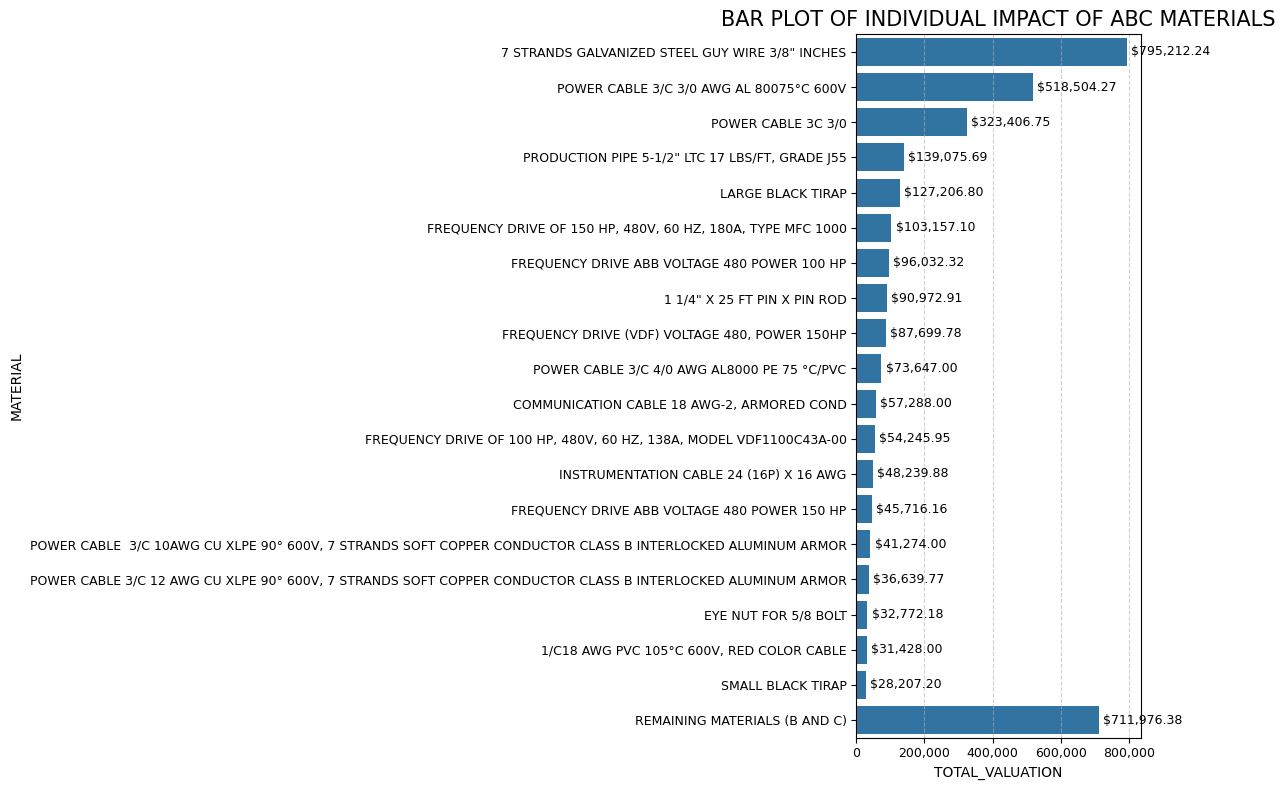

In [ ]:
plot_categorical_feature(abc_bar_dict,
                         'bar',
                         'TOTAL_VALUATION',
                         'MATERIAL',
                         True, '$'
                         )

**Observation**: The item **7 STRANDS GALVANIZED STEEL GUY WIRE 3/8 INCHES** has an individual valuation of **795,212.24 dollars**. This single material alone exceeds the combined value of all materials in the B and C categories, which total **711,916.20 dollars**.

### **MOVEMENT FREQUENCY OF CLASS A MATERIALS**

In [ ]:
a_material_list = abc_table[abc_table['ABC_CLASSIFICATION'] == 'A']['MATERIAL'].tolist()

In [ ]:
all_a_movements = valuation_df[valuation_df['MATERIAL'].isin(a_material_list)].copy()

In [ ]:
a_material_dict = {
    'DEMAND FREQUENCY FOR CLASS A MATERIALS': all_a_movements
}

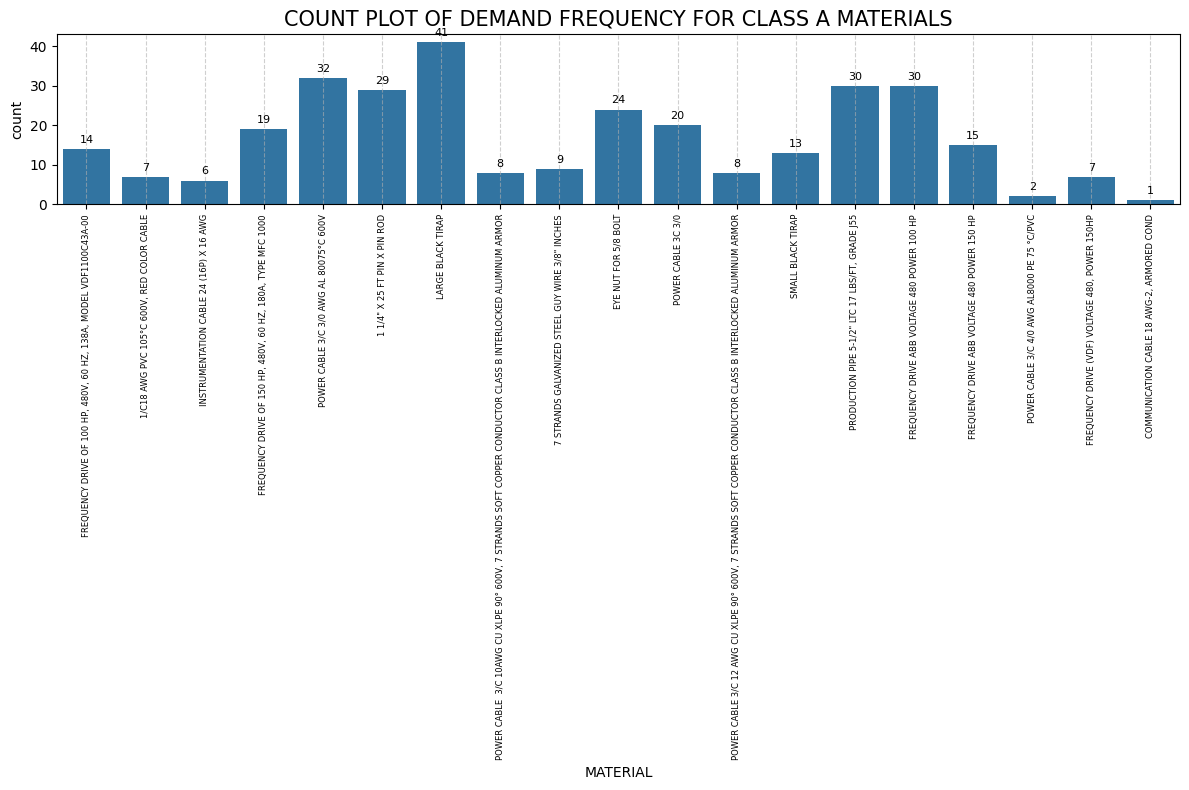

In [ ]:
plot_categorical_feature(a_material_dict,
                         'count',
                         'MATERIAL'
                         )

**Observation**: Although the **7 STRANDS GALVANIZED STEEL GUY WIRE 3/8 INCHES** has fewer than **10 outputs**, it represents the highest monetary value in the inventory. In contrast, the **Large BLACK TIRAP** has a significantly higher turnover with **40 outputs**; however, despite its high volume, its total valuation does not come close to that of the galvanized guy wire.

### **TOTAL INVENTORY REPRESENTATION AND ITS VALUE**

In [ ]:
melted_df = abc_summary[['ABC_CLASSIFICATION', '%_MATERIAL', '%_TOTAL_VALUATION']].copy()

In [ ]:
melted_df

,ABC_CLASSIFICATION,%_MATERIAL,%_TOTAL_VALUATION
0,A,2.81,79.32
1,B,9.75,15.63
2,C,87.44,5.05


In [ ]:
melted_df.columns = ['ABC_CLASSIFICATION', 'INVENTORY SHARE (%)', 'ECONOMIC VALUE (%)']

In [ ]:
melted_plot = melted_df.melt(id_vars='ABC_CLASSIFICATION', var_name='METRIC', value_name='PERCENTAGE')

In [ ]:
abc_arg_one = {
    "hue": "METRIC",
    "palette": "muted"
}

In [ ]:
abc_bar_dict_one = {'TOTAL INVENTORY REPRESENTATION AND ITS VALUE': melted_plot}

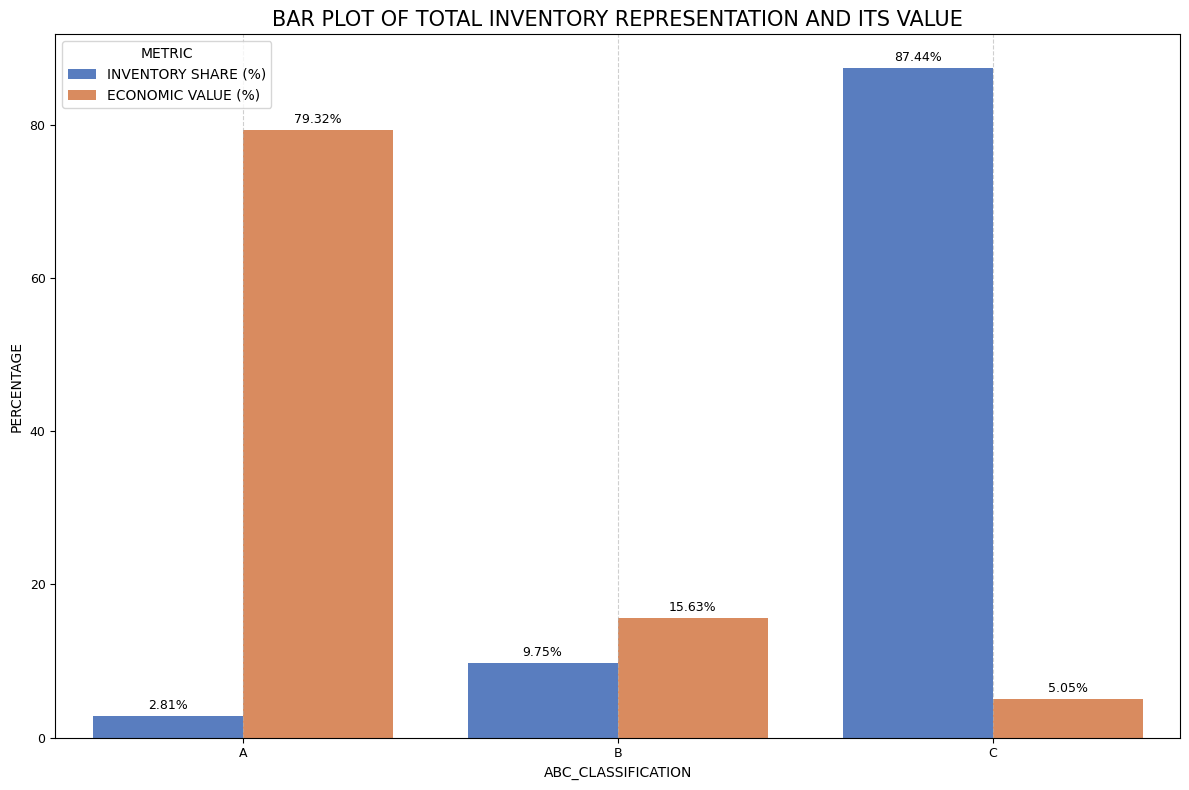

In [ ]:
plot_categorical_feature(abc_bar_dict_one,
                         'bar',
                         'ABC_CLASSIFICATION',
                         'PERCENTAGE',
                         **abc_arg_one
                         )

**Observation**: In the **TOTAL INVENTORY REPRESENTATION AND ITS VALUE** bar plot, I noticed that **Category A** represents only **2.81%** of the total inventory but accounts for **79.32%** of the total value. **Category B** represents **9.75%** of the items and **15.63%** of the value. Finally, **Category C** represents **87.44%** of the total materials while contributing only **5.05%** of the value.

### **DISTRIBUTION OF MATERIAL DELIVERIES PER DEPARTMENT**

In [ ]:
# merging outbound movements with abc classification
dept_analysis_df = clean_dfs['CLEAN OUTPUTS'].merge(
    abc_table[['MATERIAL', 'ABC_CLASSIFICATION']],
    on='MATERIAL',
    how='left'
)

In [ ]:
dept_analysis_df['ABC_CLASSIFICATION'] = dept_analysis_df['ABC_CLASSIFICATION'].replace({'B': '(B & C)', 'C': '(B & C)'})

In [ ]:
dept_mat_dist = dept_analysis_df.groupby(['REQUESTING_DEPARTMENT', 'ABC_CLASSIFICATION']).agg({
    'MATERIAL': 'count'
}).reset_index()

In [ ]:
dept_mat_dist = dept_mat_dist.rename(columns={'MATERIAL': 'OUTBOUND_TRANSACTIONS'})

In [ ]:
# dept_mat_dist ------> view of material issue transactions by abc classification

In [ ]:
# Ordering abc classification for hue
dept_mat_dist['ABC_CLASSIFICATION'] = pd.Categorical(dept_mat_dist['ABC_CLASSIFICATION'], categories=['A', '(B & C)'], ordered=True)

In [ ]:
dept_plot_dist = {'OUTBOUND TRANSACTIONS': dept_mat_dist}

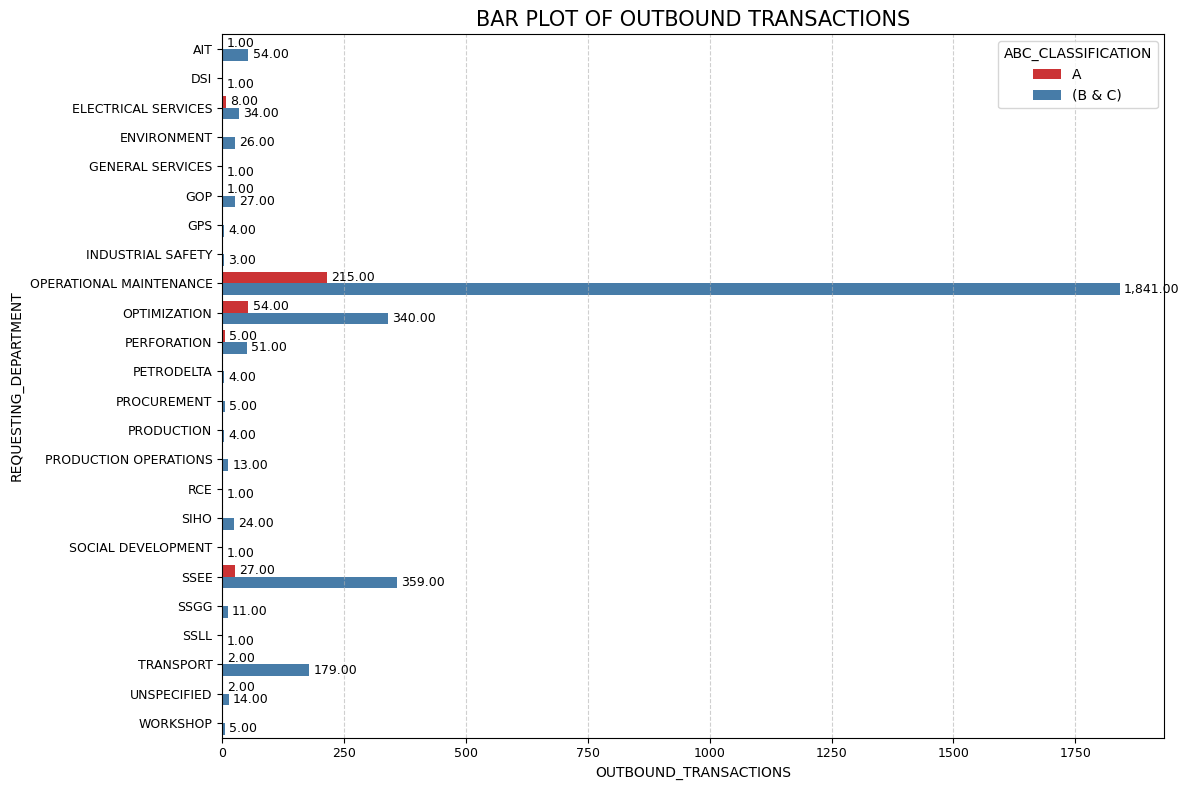

In [ ]:
plot_categorical_feature(dept_plot_dist,
                         'bar',
                         'OUTBOUND_TRANSACTIONS',
                         'REQUESTING_DEPARTMENT',
                         hue='ABC_CLASSIFICATION',
                         palette='Set1',
                         unit=''
                         )

**Observation**: The departments with the highest demand for Category A materials are **OPERATIONAL MAINTENANCE, SSEE, PERFORATION, OPTIMIZATION, and ELECTRICAL SERVICES**.

The **OPERATIONAL MAINTENANCE** department leads the material consumption across all categories, recording **215 orders** for Category A and **1,859 orders** for Categories (B & C). In contrast, the **PERFORATION department** shows a significantly lower volume of high-value requests, with only **5 orders** for Category A and a combined total of **51 orders** for Categories (B & C).

Finally, a critical anomaly was detected; an unspecified department (not tabulated) requested **3 orders** of Category A materials. Given that these represent the highest-value assets in the inventory, it is imperative to conduct an audit of the warehouse personnel or the inventory manager to clarify and assign these high-value movements to the correct department.

#### **CATEGORY A MATERIALS ISSUED TO UNSPECIFIED DEPARTMENTS**

In [ ]:
unspecified_dept_materials = dept_analysis_df[
    (dept_analysis_df['REQUESTING_DEPARTMENT'] == 'UNSPECIFIED')
].copy()

In [ ]:
unspecified_dept_materials = unspecified_dept_materials.sort_values(by='ABC_CLASSIFICATION', ascending=False)

In [ ]:
unspecified_dept_materials

,DATE,MATERIAL,UNIT_OF_MEASURE,QUANTITY,REQUESTING_DEPARTMENT,REQUESTED BY,APPROVED BY,ABC_CLASSIFICATION
844,2025-11-19,"1 1/4"" X 25 FT PIN X PIN ROD",UNIT,94,UNSPECIFIED,UNSPECIFIED,UNSPECIFIED,A
1110,2025-06-06,LARGE BLACK TIRAP,UNIT,100,UNSPECIFIED,WILIANS CONDALES,WILIANS CONDALES,A
1107,2025-06-06,LEATHER GLOVES,PAIR,12,UNSPECIFIED,WILIANS CONDALES,WILIANS CONDALES,(B & C)
1108,2025-06-06,RUBBER SPLICING TAPE 23,ROLL,2,UNSPECIFIED,WILIANS CONDALES,WILIANS CONDALES,(B & C)
1109,2025-06-06,ELECTRICAL TAPE 33,ROLL,2,UNSPECIFIED,WILIANS CONDALES,WILIANS CONDALES,(B & C)
1112,2025-06-06,TERMINAL TYPE BARRACUDA BIMETAL DOUBLE EYE FOR...,UNIT,6,UNSPECIFIED,WILIANS CONDALES,WILIANS CONDALES,(B & C)
1116,2025-06-07,TERMINAL TYPE BARRACUDA 2/0,UNIT,6,UNSPECIFIED,UNSPECIFIED,WILIANS CONDALES,(B & C)
1117,2025-06-08,TERMINAL TYPE BARRACUDA 2/0,UNIT,6,UNSPECIFIED,FELIX SANCHEZ,WILIANS CONDALES,(B & C)
1118,2025-06-08,RUBBER SPLICING TAPE 23,ROLL,1,UNSPECIFIED,FELIX SANCHEZ,WILIANS CONDALES,(B & C)
1119,2025-06-08,ELECTRICAL TAPE 33,ROLL,1,UNSPECIFIED,FELIX SANCHEZ,WILIANS CONDALES,(B & C)


**Observation**: This section details the materials issued from the warehouse without a designated recipient department; specifically, the Category A materials delivered under an "**Unspecified**" status were the **1 1/4" X 25 FT PIN X PIN ROD** and the **LARGE BLACK TIRAP**, along with the other Category **(B & C)** items tabulated in the table above. These findings must be reported immediately to the Inventory Integrity Manager to clarify these movements, ensure accountability, and prevent financial discrepancies in the high-value stock records.

## **7. ECONOMIC IMPACT BY DEPARTMENT**

In [ ]:
economic_impact = clean_dfs['CLEAN OUTPUTS'].merge(
    abc_table[['MATERIAL', 'MEDIAN_UNIT_PRICE', 'ABC_CLASSIFICATION']],
    on='MATERIAL',
    how='left'
).copy()

In [ ]:
economic_impact['ABC_CLASSIFICATION'] = economic_impact['ABC_CLASSIFICATION'].replace({'B': '(B & C)', 'C': '(B & C)'})

In [ ]:
economic_impact['ECONOMIC_IMPACT'] = economic_impact['QUANTITY'] * economic_impact['MEDIAN_UNIT_PRICE']

In [ ]:
economic_impact_summary = economic_impact.groupby(['REQUESTING_DEPARTMENT', 'ABC_CLASSIFICATION']).agg({
    "ECONOMIC_IMPACT": 'sum',

}).reset_index()

In [ ]:
# display(economic_impact_summary)----> economic impact visualization table by department

In [ ]:
# Ordering abc classification for hue
economic_impact_summary['ABC_CLASSIFICATION'] = pd.Categorical(economic_impact_summary['ABC_CLASSIFICATION'], categories=['A', '(B & C)'], ordered=True)

In [ ]:
economic_impact_summary['ABC_CLASSIFICATION'] = pd.Categorical(economic_impact_summary['ABC_CLASSIFICATION'], categories=['A', '(B & C)'], ordered=True)

In [ ]:
economic_impact_plot = {
    'ECONOMIC IMPACT BY MATERIAL CLASSIFICATION IN DELIVERED DEPARTMENTS': economic_impact_summary
}

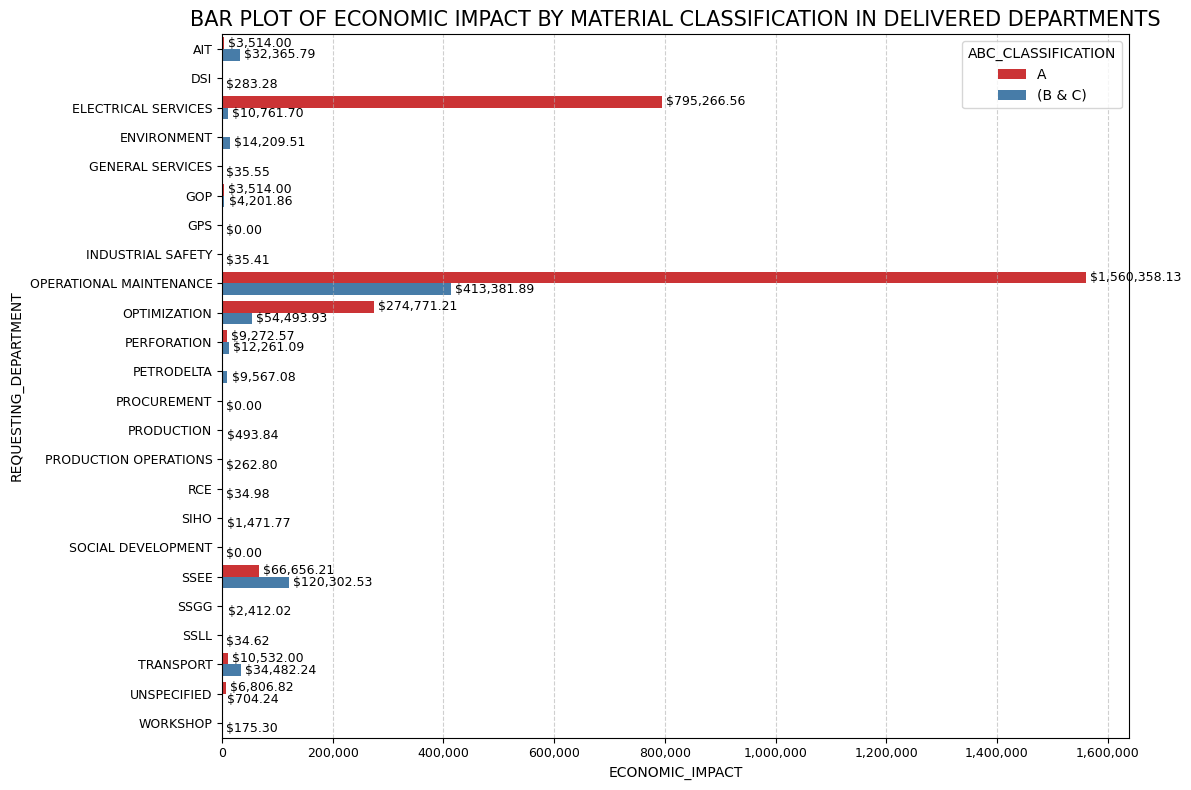

In [ ]:
plot_categorical_feature(economic_impact_plot,
                         'bar',
                         'ECONOMIC_IMPACT',
                         'REQUESTING_DEPARTMENT',
                         hue='ABC_CLASSIFICATION',
                         palette='Set1',
                         unit='$',
                         use_formatter=True
                         )

**Observation**: A comprehensive data analysis reveals that the **OPERATIONAL MAINTENANCE** department not only leads in order frequency across all categories but also exerts an overwhelming economic dominance, totaling **1,560,358.13 dollars** in **Class A** materials and **413,381.89 dollars** in **Class (B & C)** materials. Concurrently, a critical anomaly is identified within **ELECTRICAL SERVICES**, which, despite recording only 8 requests, represents the second-highest financial impact in **Class A** materials at **795,266.56 dollars**, suggesting an exceptionally high cost per dispatch; a follow-up review of the specific materials allocated or delivered will be conducted to further investigate this finding. Finally, **7,511.06 dollars** in material outflows were detected without specific departmental assignment (**6,806.82 dollars** in **Class A** and **704.24 dollars** in **Class (B & C)**), making it imperative to clarify the destination of these resources and validate **Unspecified** records to ensure the full integrity and transparency of inventory control.

In [ ]:
outputs_elec_services = dept_analysis_df[
    (dept_analysis_df['REQUESTING_DEPARTMENT'] == 'ELECTRICAL SERVICES')
].copy()

In [ ]:
outputs_elec_services = outputs_elec_services.sort_values(by='ABC_CLASSIFICATION', ascending=False)

In [ ]:
# display(outputs_elec_services) ---> output registers of ELECTRICAL SERVICES department

**Observation**: A review of the **ELECTRICAL SERVICES** records confirms that its high financial impact —despite having only 8 **Class A** requests— is driven by the procurement of **7 STRANDS GALVANIZED STEEL GUY WIRE 3/8 INCHES**. This item is the most valuable material in the entire inventory, with its valuation alone exceeding the combined total of all **Class (B & C)** materials. The magnitude of this expenditure is directly linked to the high volume of meters requested in these specific orders.

## **8. ACQUISITION FREQUENCY OF CLASS A AND (B & C) MATERIALS BY SUPPLIERS**

In [ ]:
add_supplier = clean_dfs['CLEAN ENTRIES'].merge(
    abc_table[['MATERIAL', 'ABC_CLASSIFICATION']],
    on= 'MATERIAL',
    how='left'
).copy()

In [ ]:
# display(add_supplier) ----> material procurement table by supplier

**Observation**: I notice to create the **add_supplier** dataframe some materials don't have **ABC classification** because they don't demand, so they were not tabulated. Therefore, I will impute them as **NO CATEGORY**.

In [ ]:
add_supplier['ABC_CLASSIFICATION'] = add_supplier['ABC_CLASSIFICATION'].replace(np.nan, 'DEAD STOCK')

### **9. FREQUENCY OF MATERIAL ACQUISITION BY SUPPLIERS**

In [ ]:
freq_suppliers = {'FREQUENCY OF MATERIAL ACQUISITION BY SUPPLIERS': add_supplier}

In [ ]:
color1 = terra_palette = {'A': '#9B2226', 'B': '#CA6702', 'C': '#EE9B00', 'DEAD STOCK': '#AEB6BF'}

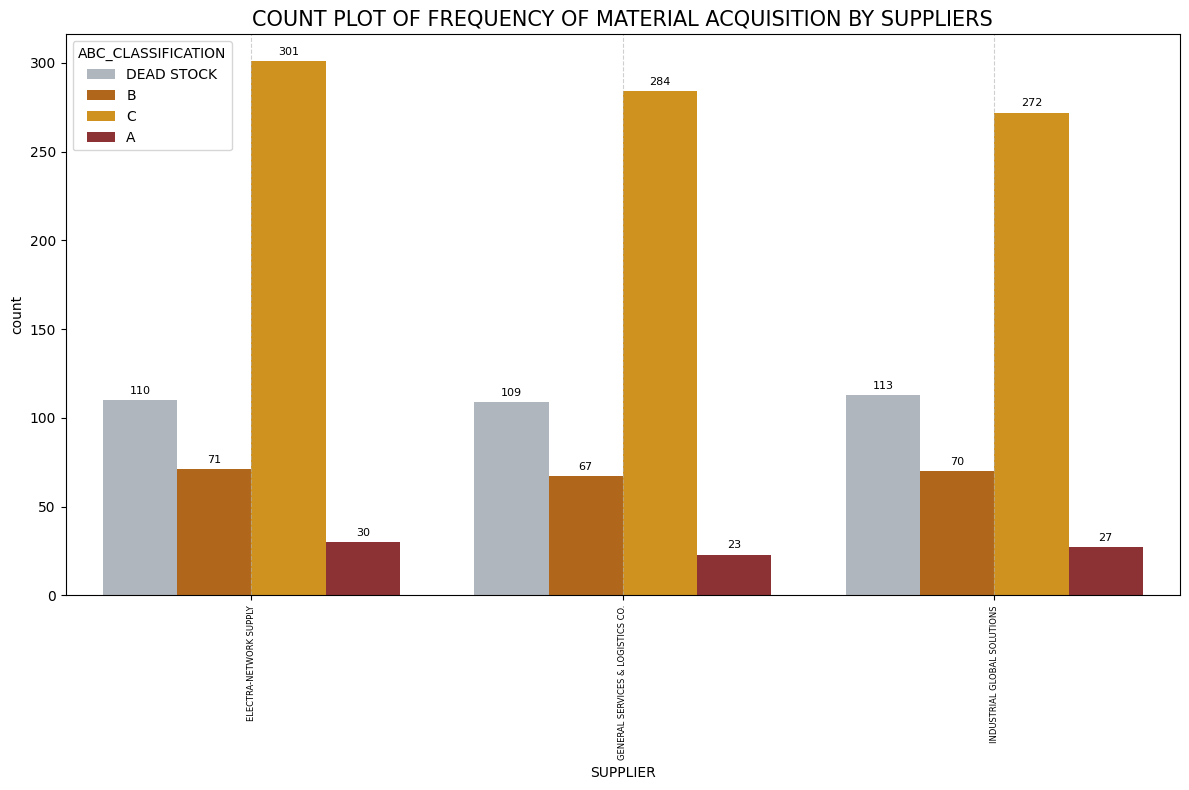

In [ ]:
plot_categorical_feature(freq_suppliers,
                         'count',
                         'SUPPLIER',
                         hue='ABC_CLASSIFICATION',
                         palette=color1
                         )

**Observation**: According to the frequency plot, **ELECTRA-NETWORK SUPPLY** leads the delivery of **Class A** materials with 30 entries, followed by **INDUSTRIAL GLOBAL SOLUTIONS** (27) and **GENERAL SERVICES & LOGISTICS CO.** (23).

Additionally, I identified several unclassified materials due to a lack of demand. It is imperative to analyze why these were originally requested and why they remain stagnant. This **Dead Stock** is concerning as it represents a significant opportunity cost, storage expenses, and potential expiration risks.

In [ ]:
no_category_mat = add_supplier.loc[add_supplier['ABC_CLASSIFICATION'] == 'DEAD STOCK', 'MATERIAL']

In [ ]:
dead_stock = pd.Series(no_category_mat.unique(), name='MATERIALS WITH NO DEMAND')

In [ ]:
# display(dead_stock) -----> dead stock visualization

**Observation**: There are 277 **dead stock** items that we need to review to understand why they have no demand.

### **Financial Value of ABC-Classified Materials per Supplier**

In [ ]:
financial_value_supplier = add_supplier.loc[:, ['MATERIAL', 'QUANTITY', 'UNIT_PRICE_USD', 'SUPPLIER', 'ABC_CLASSIFICATION']]

In [ ]:
financial_value_supplier['TOTAL_AMOUNT'] = (financial_value_supplier['QUANTITY'] * financial_value_supplier['UNIT_PRICE_USD'])

In [ ]:
financial_supplier_summary = financial_value_supplier.groupby(['SUPPLIER', 'ABC_CLASSIFICATION']).agg({
    'TOTAL_AMOUNT': 'sum'
}).reset_index()

In [ ]:
finalcial_plot = {'FINANCIAL VALUE OF ABC-CLASSIFIED MATERIALS PER SUPPLIER': financial_supplier_summary}

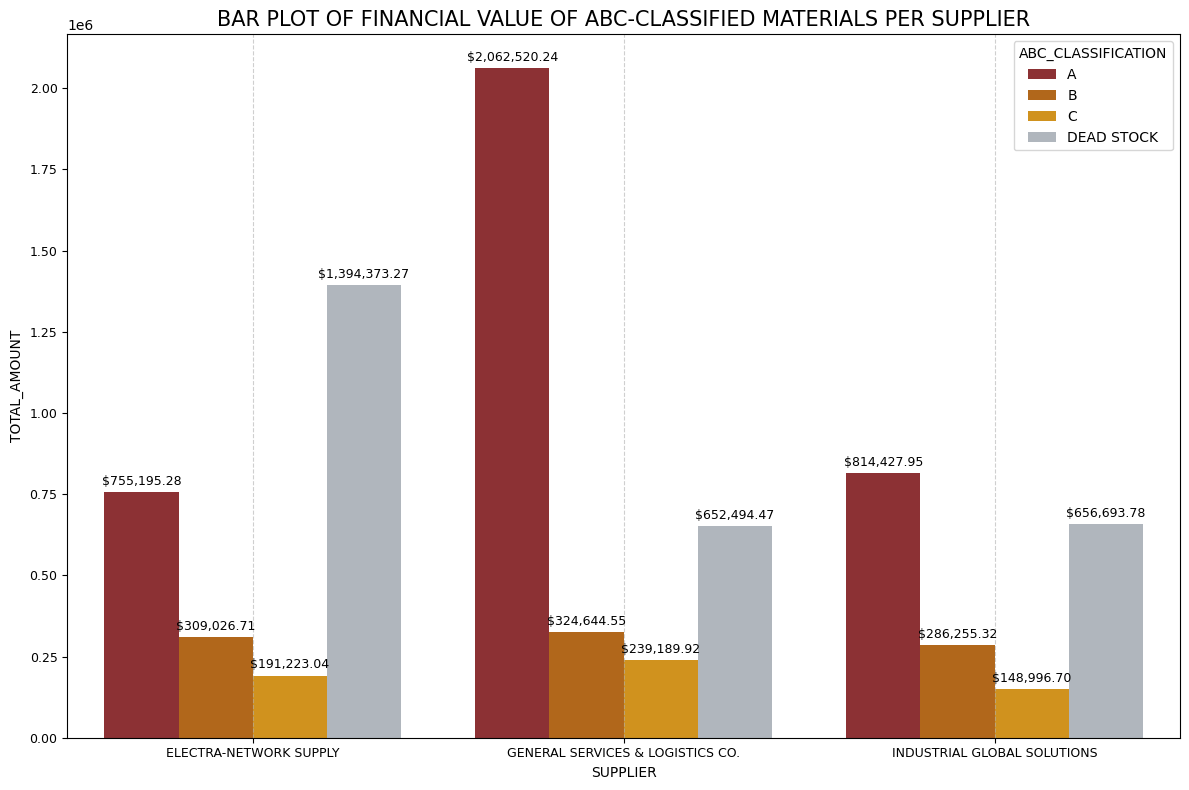

In [ ]:
plot_categorical_feature(finalcial_plot,
                         'bar',
                         'SUPPLIER',
                         'TOTAL_AMOUNT',
                         hue='ABC_CLASSIFICATION',
                         palette=color1,
                         unit='$'
                         )

**Observation**: In the procurement of **Class A materials**, the economic valuation in **USD** per supplier is as follows:

* ELECTRA-NETWORK: **\$755,195.28**
* GENERAL SERVICES & LOGISTICS CO: **\$2,062,500.24**
* INDUSTRIAL GLOBAL SOLUTIONS: **\$814,427.95**

Now, the **dead stock** has the following valuation per supplier:

* ELECTRA-NETWORK: **\$1,394,373.27**
* GENERAL SERVICES & LOGISTICS CO: **\$652,494.47**
* INDUSTRIAL GLOBAL SOLUTIONS: **\$656,693.78**

It is important to observe and restructure purchase orders because there is a total of **\$2,703,561.52** in dead stock. There are materials with expiration dates, such as nitrile gloves, among others, that were acquired but expire without being used.

## **9. CLASS A PRICE AUDIT**

In [ ]:
add_supplier_a = add_supplier[add_supplier['ABC_CLASSIFICATION'] == 'A']

/tmp/ipykernel_3691/2438346043.py:104: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


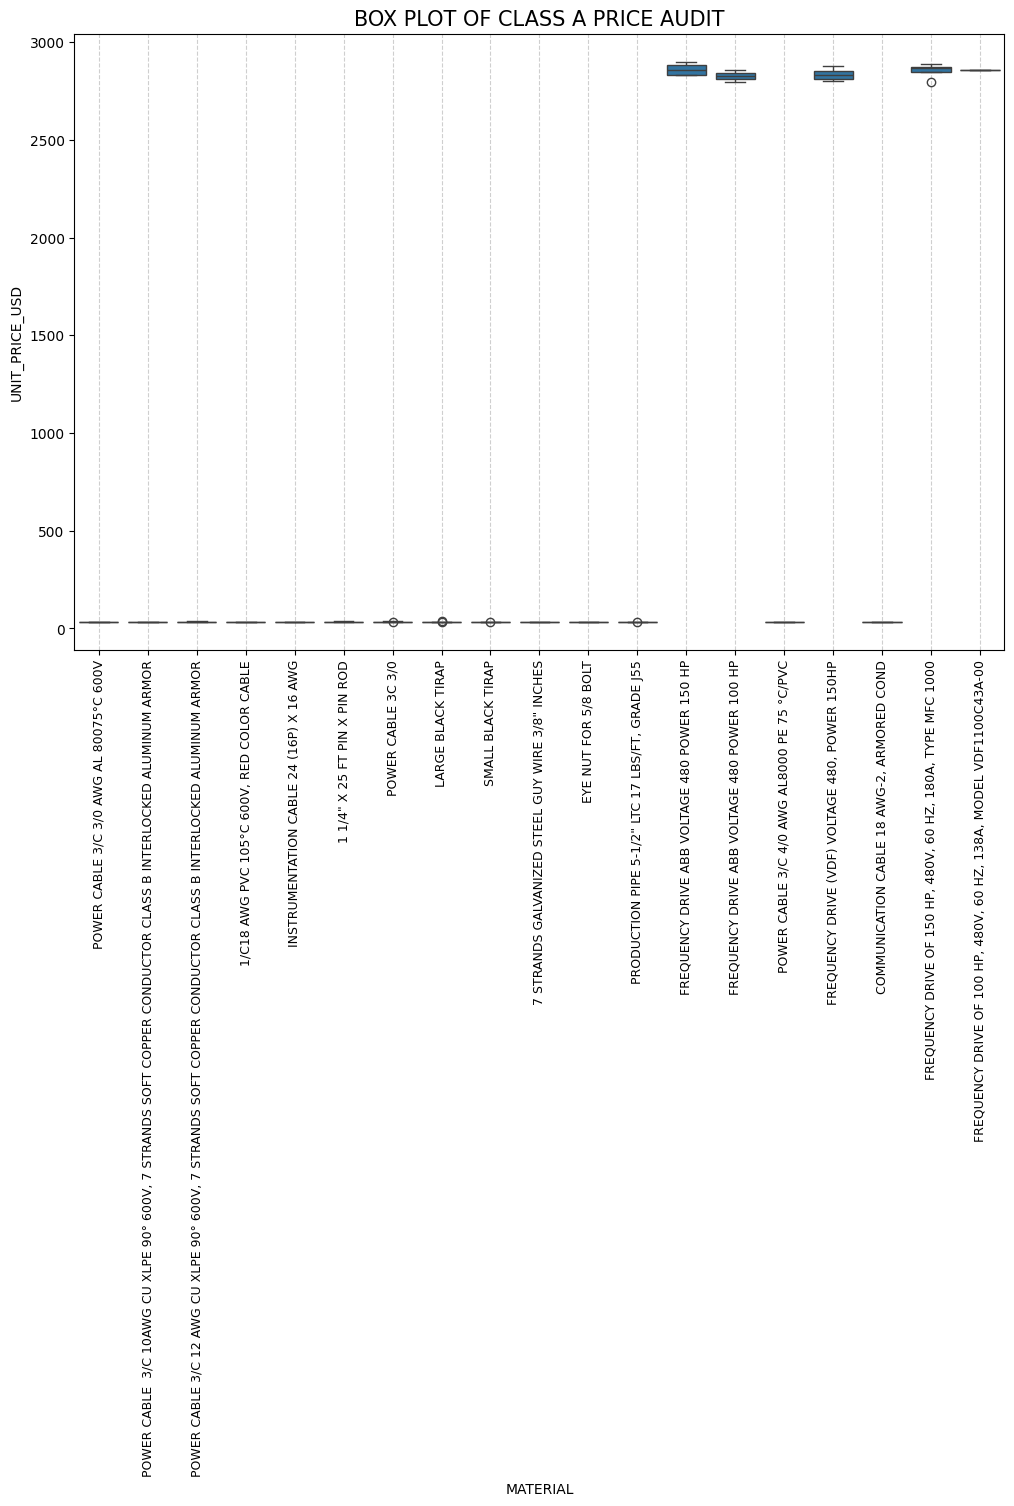

In [ ]:
plot_categorical_feature(
    {'CLASS A PRICE AUDIT': add_supplier_a},
    'box',
    ['MATERIAL'],
    'UNIT_PRICE_USD'
)

**Observation**: The box plot analysis reveals significant price or quantity outliers for the following specific materials:

* POWER CABLE 3/0

* LARGE BLACK TIRAP

* SMALL BLACK TIRAP

* PRODUCTION PIPE 5-1/2" LTC LBS/FT GADE J55

* FREQUENCY DRIVE OF 150 HP 480V 6 HZ 180 A TYPE MFC 1000

In [ ]:
def classify_z_score(col):
  col_abs = abs(col)

  if col_abs <= 1.5:
    return 'OKAY VALUES'

  elif col_abs <= 2.0:
    return 'MODERATE DEVIATION'

  elif col_abs <= 3.0:
    return 'HIGH DEVIATION'

  else:
    return 'AUDIT OUTLIER'

In [ ]:
z_score_audit = add_supplier_a.loc[:, ['MATERIAL', 'UNIT_PRICE_USD']].copy()

In [ ]:
z_score_audit['Z_SCORE'] = z_score_audit.groupby('MATERIAL')['UNIT_PRICE_USD'].transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0).round(2)

In [ ]:
z_score_audit['AUDIT_STATUS'] = z_score_audit['Z_SCORE'].apply(classify_z_score)

In [ ]:
# filtering potential audits. I am not including 'HIGH DEVIATION' or 'AUDIT OUTLIER' because such extreme outliers do not exist.
possible_audit =  z_score_audit[z_score_audit['AUDIT_STATUS'] == 'MODERATE DEVIATION']

In [ ]:
# display(possible_audit) -----> material views with outliers

## **10. MATERIAL PURCHASING PATTERNS AND INVENTORY FLOW PROGRESSIONS**

### **ENTRIES ANALYSIS**

In [ ]:
entries_concen_df = clean_dfs['CLEAN ENTRIES'].loc[:, ['DATE', 'MATERIAL', 'QUANTITY', 'UNIT_PRICE_USD', 'SUPPLIER']]

In [ ]:
entries_concen_df = entries_concen_df.merge(
    abc_table[['MATERIAL', 'ABC_CLASSIFICATION']],
    on= 'MATERIAL',
    how= 'left'
)

In [ ]:
entries_concen_df = entries_concen_df.replace(np.nan, 'NO CATEGORY')

In [ ]:
input_a = entries_concen_df.loc[entries_concen_df['ABC_CLASSIFICATION'] == 'A', :].copy()

In [ ]:
input_a['TOTAL_AMOUNT'] = input_a['QUANTITY'] * input_a['UNIT_PRICE_USD']

In [ ]:
input_a['MATERIAL'] = input_a['MATERIAL'].astype(str).str[:40] + '...'

In [ ]:
scatter_entries = {'MATERIAL CONCENTRATION IN INBOUND FLOW': input_a}

In [ ]:
scatter_color = [
    '#FF0000', '#00FF00', '#0000FF', '#FF00FF', '#00FFFF', '#FFA500',
    '#800080', '#008080', '#FFD700', '#4B0082', '#FF1493', '#00FF7F',
    '#1E90FF', '#B22222', '#FF6347', '#000080', '#ADFF2F', '#8B4513', '#333333'
]

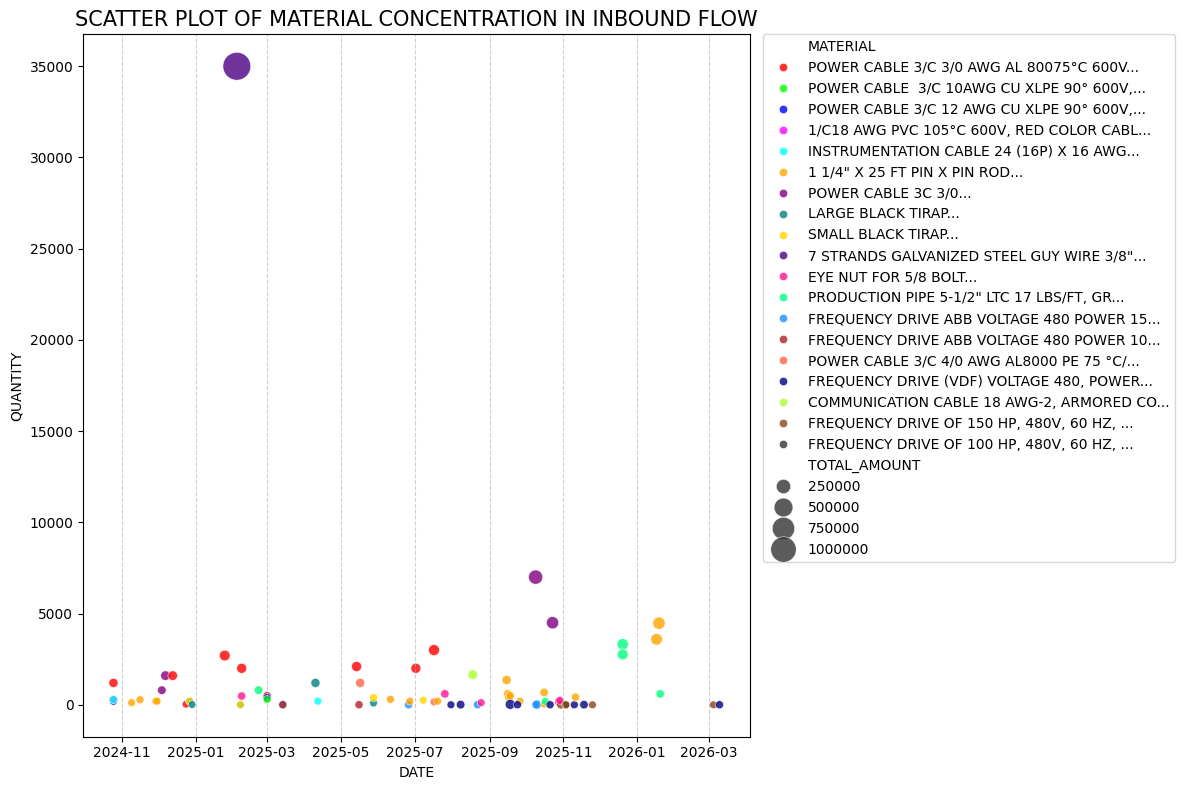

In [ ]:
plot_categorical_feature(scatter_entries,
                         'scatter',
                         'DATE',
                         'QUANTITY',
                         hue='MATERIAL',
                         size='TOTAL_AMOUNT',
                         sizes=(30,400),
                         palette=scatter_color,
                         alpha=0.8,
                         )

**Observation**: When cross-referencing the purchase volume data for **Class A** materials, a high concentration is observed in a prominent data point corresponding to the material **7 STRANDS GALVANIZED STEEL GUY WIRE 3/8 INCHES**. An outlier volume of approximately **35,000** meters was procured for this item between **January** and **March** 2025, standing out significantly above the other observations. The remaining concentrations are distributed across the scatter plot for further evaluation.

### **OUTPUTS SECTION**

In [ ]:
outputs_concen_df = clean_dfs['CLEAN OUTPUTS'].loc[:, ['DATE', 'MATERIAL', 'QUANTITY']]

In [ ]:
outputs_concen_df = outputs_concen_df.merge(
    abc_table[['MATERIAL', 'ABC_CLASSIFICATION']],
    on= 'MATERIAL',
    how= 'left'
)

In [ ]:
outputs_concen_df = outputs_concen_df.replace(np.nan, 'NO CATEGORY')

In [ ]:
output_a = outputs_concen_df.loc[outputs_concen_df['ABC_CLASSIFICATION'] == 'A', :].copy()

In [ ]:
output_a['MATERIAL'] = output_a['MATERIAL'].astype(str).str[:40] + '...'

In [ ]:
scatter_outputs = {'MATERIAL CONCENTRATION IN OUTBOUND FLOW': output_a}

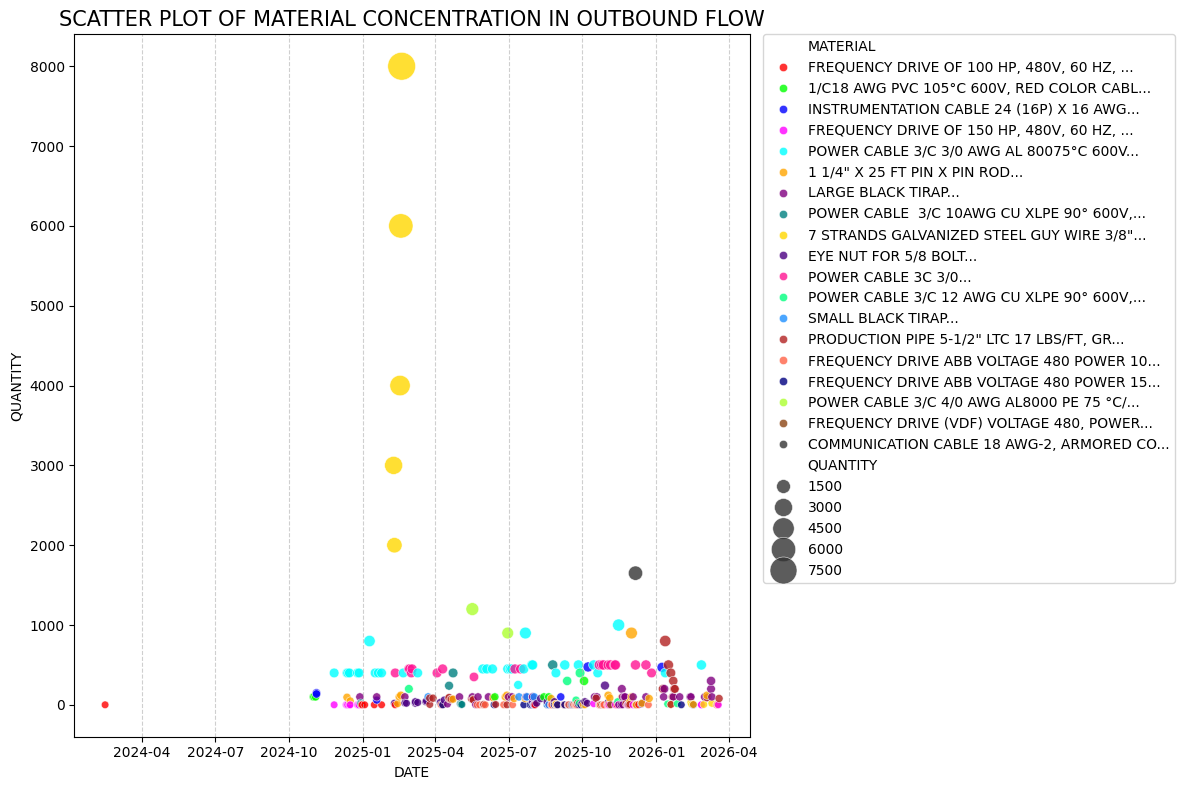

In [ ]:
plot_categorical_feature(scatter_outputs,
                         'scatter',
                         'DATE',
                         'QUANTITY',
                         hue='MATERIAL',
                         size='QUANTITY',
                         sizes=(30,400),
                         palette=scatter_color,
                         alpha=0.8,
                         )

**Observation**: **Likewise**, between **January** and **April**, a series of high-volume, consecutive dispatches was recorded for the material **7 STRANDS GALVANIZED STEEL GUY WIRE 3/8 INCHES**, featuring highly distinct individual outflows that reached 8,000, 4,000, 2,800, 2,000, and 600 meters. It is worth noting that this same scatter plot displays the distribution and behavior of both this specific item and the rest of the evaluated materials.